# 01 - Análisis Exploratorio Univariado

Este notebook profundiza el análisis univariado del panel municipio-semana de dengue en Colombia para el periodo 2010-2024. Parte de los hallazgos del notebook `00_data_understanding.ipynb` y evita repetir validaciones de integridad, cobertura o resumen global.

El objetivo aquí es caracterizar la distribución de cada variable por separado: forma, rango, ceros, dispersión, asimetría, colas, valores extremos visibles y consecuencias epidemiológicas para los notebooks posteriores. No se realiza modelado, forecasting ni análisis causal.


## 1. Configuración, carga y estilo visual

Se cargan las librerías, el dataset bruto y una columna temporal auxiliar (`week_date`) derivada de `week_start`. En este notebook `week_date` no se analiza como distribución numérica; se conserva solo como referencia temporal para perfiles univariados y para mantener coherencia con la cadena analática.


In [44]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

DATASET_PATH = Path("../data/raw/raw_dataset.csv")
EDA_FIGURES_ROOT = Path("../figures/eda_univariate")

PANORAMA_PATH = EDA_FIGURES_ROOT / "00_panorama"

EPIDEMIOLOGICAS_TOTAL_PATH = EDA_FIGURES_ROOT / "01_epidemiologicas" / "total"
EPIDEMIOLOGICAS_EDAD_PATH = EDA_FIGURES_ROOT / "01_epidemiologicas" / "edad"
EPIDEMIOLOGICAS_SEXO_PATH = EDA_FIGURES_ROOT / "01_epidemiologicas" / "sexo"

ESTRATIFICACION_PATH = EDA_FIGURES_ROOT / "02_estratificacion"
CLIMATICAS_PATH = EDA_FIGURES_ROOT / "03_climaticas"
AMBIENTALES_MACROCLIMA_PATH = EDA_FIGURES_ROOT / "04_ambientales_macroclima"
DEMOGRAFIA_FLUJO_PATH = EDA_FIGURES_ROOT / "05_demografia_flujo"

COMPARACIONES_VIOLIN_PATH = EDA_FIGURES_ROOT / "06_comparaciones_violin"
FALTANTES_PATH = EDA_FIGURES_ROOT / "07_faltantes"
CATEGORICAS_TEMPORALES_PATH = EDA_FIGURES_ROOT / "08_categoricas_temporales"

VARIABLE_FIGURE_DIRS = {
    "casos_totales": EPIDEMIOLOGICAS_TOTAL_PATH,

    "casos_0_4": EPIDEMIOLOGICAS_EDAD_PATH,
    "casos_5_14": EPIDEMIOLOGICAS_EDAD_PATH,
    "casos_15_64": EPIDEMIOLOGICAS_EDAD_PATH,
    "casos_65_plus": EPIDEMIOLOGICAS_EDAD_PATH,

    "casos_m": EPIDEMIOLOGICAS_SEXO_PATH,
    "casos_f": EPIDEMIOLOGICAS_SEXO_PATH,

    "estrato_1_2": ESTRATIFICACION_PATH,
    "estrato_3_4": ESTRATIFICACION_PATH,
    "estrato_5_plus": ESTRATIFICACION_PATH,

    "temp_mean": CLIMATICAS_PATH,
    "prec_total": CLIMATICAS_PATH,

    "ndvi_mean": AMBIENTALES_MACROCLIMA_PATH,
    "oni_anom": AMBIENTALES_MACROCLIMA_PATH,
    "oni_total": AMBIENTALES_MACROCLIMA_PATH,

    "poblacion": DEMOGRAFIA_FLUJO_PATH,
    "Flujo_in": DEMOGRAFIA_FLUJO_PATH,
}

for path in {
    PANORAMA_PATH,
    EPIDEMIOLOGICAS_TOTAL_PATH,
    EPIDEMIOLOGICAS_EDAD_PATH,
    EPIDEMIOLOGICAS_SEXO_PATH,
    ESTRATIFICACION_PATH,
    CLIMATICAS_PATH,
    AMBIENTALES_MACROCLIMA_PATH,
    DEMOGRAFIA_FLUJO_PATH,
    COMPARACIONES_VIOLIN_PATH,
    FALTANTES_PATH,
    CATEGORICAS_TEMPORALES_PATH,
}:
    path.mkdir(parents=True, exist_ok=True)

TABLES_PATH = Path("../tables/eda_univariate")
TABLES_PATH.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "epidemiologica": "#4C78A8",
    "edad": "#72B7B2",
    "sexo": "#F58518",
    "estrato": "#54A24B",
    "climatica": "#E45756",
    "ambiental": "#B279A2",
    "demografica": "#9D755D",
    "flujo": "#FF9DA6",
    "gris": "#6B7280",
}

PLOT_SAMPLE_SIZE = 120_000
RANDOM_STATE = 42

df = pd.read_csv(DATASET_PATH)
df["week_date"] = pd.to_datetime(df["week_start"], errors="coerce")

df.head()


,COD_MUN_N,ANO,SEMANA,casos_totales,casos_0_4,casos_5_14,casos_15_64,casos_65_plus,casos_m,casos_f,estrato_1_2,estrato_3_4,estrato_5_plus,week_start,MES,temp_mean,prec_total,ndvi_mean,oni_anom,oni_total,Flujo_in,poblacion,week_date
0,5001,2010,1,38,1,5,28,4,14,24,0,0,0,2010-01-04,1,24.804,2.800,0.611,1.500,28.140,0.000,2359801,2010-01-04
1,5001,2010,2,43,1,8,31,3,19,24,0,0,0,2010-01-11,1,25.143,0.000,0.611,1.500,28.140,80.349,2359801,2010-01-11
2,5001,2010,3,44,1,3,35,5,24,20,0,0,0,2010-01-18,1,25.893,0.000,0.611,1.500,28.140,85.677,2359801,2010-01-18
3,5001,2010,4,58,3,10,39,6,27,31,0,0,0,2010-01-25,1,23.764,29.000,0.611,1.500,28.140,104.969,2359801,2010-01-25
4,5001,2010,5,96,2,15,71,8,54,42,0,0,0,2010-02-01,2,26.393,0.000,0.528,1.220,28.090,118.953,2359801,2010-02-01


## 2. Alcance del análisis univariado

No todas las columnas numéricas deben tratarse como distribuciones epidemiológicas. Los identificadores y variables temporales discretas sirven para indexar, ordenar o agrupar, pero no para interpretar medias, asimetrías o boxplots como si fueran mediciones continuas.


In [45]:
undistributed_columns = pd.DataFrame(
    [
        ["COD_MUN_N", "Identificador geográfico", "Contar municipios y usar como llave; no interpretar su distribución."],
        ["ANO", "Identificador temporal", "Usar para cortes temporales; no interpretar media o boxplot."],
        ["SEMANA", "Identificador temporal", "Usar como semana epidemiológica; no tratar como variable continua."],
        ["week_date", "Fecha", "Usar para ordenar y perfilar temporalmente; el análisis temporal principal queda para el notebook 05."],
        ["week_start", "Fecha original", "Fuente de week_date; no analizar distributivamente."],
        ["MES", "Categoría temporal", "Tratar como variable categórica/estacional, no como número continuo."],
    ],
    columns=["Variable", "Rol", "Tratamiento en este notebook"],
)

undistributed_columns.to_csv(
    TABLES_PATH / "variables_not_for_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)

undistributed_columns


,Variable,Rol,Tratamiento en este notebook
0,COD_MUN_N,Identificador geográfico,Contar municipios y usar como llave; no interp...
1,ANO,Identificador temporal,Usar para cortes temporales; no interpretar me...
2,SEMANA,Identificador temporal,Usar como semana epidemiológica; no tratar com...
3,week_date,Fecha,Usar para ordenar y perfilar temporalmente; el...
4,week_start,Fecha original,Fuente de week_date; no analizar distributivam...
5,MES,Categoría temporal,"Tratar como variable categórica/estacional, no..."


## 3. Diccionario heredado y grupos analáticos

Se hereda el contexto epidemiológico documentado en `00_data_understanding.ipynb`. La organización temática evita mezclar conteos de casos, variables climáticas, ambientales, demográficas y movilidad, porque sus escalas y mecanismos generadores son distintos.


In [14]:
variable_dictionary = {
    "casos_totales": {
        "tipo": "Entero (conteo)",
        "rol": "Variable epidemiológica principal",
        "descripcion": "Total de casos de dengue reportados en municipio-semana.",
    },
    "casos_0_4": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación por edad",
        "descripcion": "Casos de dengue en edades 0-4 años.",
    },
    "casos_5_14": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación por edad",
        "descripcion": "Casos de dengue en edades 5-14 años.",
    },
    "casos_15_64": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación por edad",
        "descripcion": "Casos de dengue en edades 15-64 años.",
    },
    "casos_65_plus": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación por edad",
        "descripcion": "Casos de dengue en edades 65+ años.",
    },
    "casos_m": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación por sexo",
        "descripcion": "Casos de dengue reportados en hombres.",
    },
    "casos_f": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación por sexo",
        "descripcion": "Casos de dengue reportados en mujeres.",
    },
    "estrato_1_2": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación socioeconómica parcial",
        "descripcion": "Casos con registro en estratos socioeconómicos 1-2; no necesariamente suma casos_totales.",
    },
    "estrato_3_4": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación socioeconómica parcial",
        "descripcion": "Casos con registro en estratos socioeconómicos 3-4; no necesariamente suma casos_totales.",
    },
    "estrato_5_plus": {
        "tipo": "Entero (conteo)",
        "rol": "Estratificación socioeconómica parcial",
        "descripcion": "Casos con registro en estratos socioeconómicos 5+; no necesariamente suma casos_totales.",
    },
    "temp_mean": {
        "tipo": "Decimal (grados Celsius)",
        "rol": "Variable climática",
        "descripcion": "Temperatura media semanal disponible para una fracción del panel.",
    },
    "prec_total": {
        "tipo": "Decimal (mm)",
        "rol": "Variable climática",
        "descripcion": "Precipitación total semanal acumulada.",
    },
    "ndvi_mean": {
        "tipo": "Decimal (índice)",
        "rol": "Variable ambiental",
        "descripcion": "Índice de vegetación de diferencia normalizada promedio.",
    },
    "oni_anom": {
        "tipo": "Decimal (anomalía)",
        "rol": "Variable climática oceánica",
        "descripcion": "Anomalía del Oceanic Niño Index, proxy de condiciones El Niño/La Niña.",
    },
    "oni_total": {
        "tipo": "Decimal (índice)",
        "rol": "Variable climática oceánica",
        "descripcion": "Valor absoluto del índice oceánico asociado al ONI.",
    },
    "poblacion": {
        "tipo": "Entero (conteo)",
        "rol": "Variable demográfica",
        "descripcion": "Población municipal anual asociada al registro municipio-semana.",
    },
    "Flujo_in": {
        "tipo": "Decimal (flujo/índice)",
        "rol": "Variable de movilidad",
        "descripcion": "Indicador de movilidad entrante hacia el municipio.",
    },
}

variable_groups = {
    "Epidemiológicas - total": ["casos_totales"],
    "Epidemiológicas - edad": ["casos_0_4", "casos_5_14", "casos_15_64", "casos_65_plus"],
    "Epidemiológicas - sexo": ["casos_m", "casos_f"],
    "Estratificación socioeconómica": ["estrato_1_2", "estrato_3_4", "estrato_5_plus"],
    "Climáticas": ["temp_mean", "prec_total"],
    "Ambientales y macroclima": ["ndvi_mean", "oni_anom", "oni_total"],
    "Demográficas y flujo": ["poblacion", "Flujo_in"],
}

variables_analisis = [var for variables in variable_groups.values() for var in variables]

pd.DataFrame(variable_dictionary).T.rename_axis("variable")


,tipo,rol,descripcion
variable,,,
casos_totales,Entero (conteo),Variable epidemiológica principal,Total de casos de dengue reportados en municip...
casos_0_4,Entero (conteo),Estratificación por edad,Casos de dengue en edades 0-4 años.
casos_5_14,Entero (conteo),Estratificación por edad,Casos de dengue en edades 5-14 años.
casos_15_64,Entero (conteo),Estratificación por edad,Casos de dengue en edades 15-64 años.
casos_65_plus,Entero (conteo),Estratificación por edad,Casos de dengue en edades 65+ años.
casos_m,Entero (conteo),Estratificación por sexo,Casos de dengue reportados en hombres.
casos_f,Entero (conteo),Estratificación por sexo,Casos de dengue reportados en mujeres.
estrato_1_2,Entero (conteo),Estratificación socioeconómica parcial,Casos con registro en estratos socioeconómicos...
estrato_3_4,Entero (conteo),Estratificación socioeconómica parcial,Casos con registro en estratos socioeconómicos...


## 4. Funciones auxiliares

Las funciones siguientes estandarizan el análisis por variable. Para cada una calculan tipo, rango, faltantes, ceros, media, mediana, desviación estándar, asimetría y curtosis; además generan histograma con KDE y boxplot lado a lado. En variables no negativas y muy asimétricas se agrega comparación visual en escala lineal versus `log1p`.


In [16]:
def sample_for_plot(series, n=PLOT_SAMPLE_SIZE):
    """Muestra reproducible para graficar sin cambiar las estadísticas reportadas."""
    clean = series.dropna()
    if len(clean) > n:
        return clean.sample(n=n, random_state=RANDOM_STATE)
    return clean


def pct_zeros(series):
    clean = series.dropna()
    if clean.empty:
        return np.nan
    return (clean.eq(0).mean() * 100)


def resumen_variable(variable):
    series = df[variable]
    clean = series.dropna()
    return pd.Series(
        {
            "tipo_pandas": str(series.dtype),
            "n": int(series.shape[0]),
            "n_no_nulos": int(clean.shape[0]),
            "faltantes_%": series.isna().mean() * 100,
            "ceros_%": pct_zeros(series) if pd.api.types.is_numeric_dtype(series) else np.nan,
            "min": clean.min() if not clean.empty else np.nan,
            "q05": clean.quantile(0.05) if not clean.empty else np.nan,
            "q25": clean.quantile(0.25) if not clean.empty else np.nan,
            "media": clean.mean() if not clean.empty else np.nan,
            "mediana": clean.median() if not clean.empty else np.nan,
            "q75": clean.quantile(0.75) if not clean.empty else np.nan,
            "q95": clean.quantile(0.95) if not clean.empty else np.nan,
            "max": clean.max() if not clean.empty else np.nan,
            "std": clean.std() if not clean.empty else np.nan,
            "skewness": clean.skew() if clean.shape[0] > 2 else np.nan,
            "kurtosis": clean.kurt() if clean.shape[0] > 3 else np.nan,
            "valores_unicos": int(clean.nunique()),
        }
    )


def tabla_resumen(variables):
    tabla = pd.DataFrame({var: resumen_variable(var) for var in variables}).T
    columnas_redondeo = [
        "faltantes_%", "ceros_%", "min", "q05", "q25", "media", "mediana",
        "q75", "q95", "max", "std", "skewness", "kurtosis"
    ]
    tabla[columnas_redondeo] = tabla[columnas_redondeo].astype(float).round(3)
    return tabla


def plot_hist_box(variable, titulo=None, color="#4C78A8", bins=60, kde=True):
    titulo = titulo or variable
    datos = sample_for_plot(df[variable])
    if datos.empty:
        display(Markdown(f"**{variable}:** no hay datos no nulos para graficar."))
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 1]})

    sns.histplot(datos, bins=bins, kde=kde and datos.nunique() > 10, color=color, ax=axes[0])
    axes[0].set_title(f"Histograma y KDE: {titulo}")
    axes[0].set_xlabel(titulo)
    axes[0].set_ylabel("Frecuencia")

    sns.boxplot(x=datos, color=color, ax=axes[1], fliersize=2)
    axes[1].set_title(f"Boxplot: {titulo}")
    axes[1].set_xlabel(titulo)

    fig.suptitle(f"Distribución univariada de {titulo}", fontsize=13, y=1.03)
    plt.tight_layout()
    output_dir = VARIABLE_FIGURE_DIRS[variable]
    fig.savefig(output_dir / f"{variable}_hist_box.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_linear_vs_log(variable, titulo=None, color="#4C78A8", bins=60):
    titulo = titulo or variable
    datos = sample_for_plot(df[variable])
    datos = datos[datos >= 0].dropna()
    if datos.empty:
        display(Markdown(f"**{variable}:** no es candidata para transformación logarítmica porque no tiene valores no negativos no nulos."))
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.histplot(datos, bins=bins, kde=datos.nunique() > 10, color=color, ax=axes[0])
    axes[0].set_title("Escala lineal")
    axes[0].set_xlabel(titulo)
    axes[0].set_ylabel("Frecuencia")

    sns.histplot(np.log1p(datos), bins=bins, kde=datos.nunique() > 10, color=color, ax=axes[1])
    axes[1].set_title("Transformación log1p")
    axes[1].set_xlabel(f"log1p({titulo})")
    axes[1].set_ylabel("Frecuencia")

    fig.suptitle(f"Comparación lineal vs log1p: {titulo}", fontsize=13, y=1.03)
    plt.tight_layout()
    output_dir = VARIABLE_FIGURE_DIRS[variable]
    fig.savefig(output_dir / f"{variable}_linear_vs_log1p.png", dpi=300, bbox_inches="tight")
    plt.show()


def interpretar_variable(variable):
    info = variable_dictionary[variable]
    stats = resumen_variable(variable)
    piezas = [
        f"**{variable}** ({info['tipo']}). {info['descripcion']}",
        f"Rango observado: `{stats['min']:.3g}` a `{stats['max']:.3g}`; mediana `{stats['mediana']:.3g}`; media `{stats['media']:.3g}`.",
    ]

    if stats["faltantes_%"] >= 30:
        piezas.append(f"Presenta faltantes altos (`{stats['faltantes_%']:.1f}%`), por lo que debe tratarse explícitamente en imputación o análisis de sensibilidad.")
    elif stats["faltantes_%"] > 0:
        piezas.append(f"Tiene faltantes bajos/moderados (`{stats['faltantes_%']:.1f}%`), suficientes para documentar antes de cualquier transformación.")

    if stats["ceros_%"] >= 50:
        piezas.append(f"La masa en cero es dominante (`{stats['ceros_%']:.1f}%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión.")
    elif stats["ceros_%"] > 0:
        piezas.append(f"Incluye ceros (`{stats['ceros_%']:.1f}%`), que deben preservarse porque suelen tener significado epidemiológico o ambiental.")

    if pd.notna(stats["skewness"]):
        if stats["skewness"] > 2:
            piezas.append("La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.")
        elif stats["skewness"] < -1:
            piezas.append("La asimetría negativa sugiere concentración en valores altos con cola hacia valores bajos; conviene revisarla junto con el mecanismo de medición.")
        else:
            piezas.append("La asimetría no domina la forma de la distribución, por lo que la escala original es interpretable para descripción univariada.")

    implicaciones = {
        "casos_totales": "Implicación: considerar `log1p(casos_totales)` o enfoques robustos en notebooks posteriores; la variable no debe normalizarse ignorando la masa en cero.",
        "temp_mean": "Implicación: su alto faltante impide asumir representatividad completa del panel climático sin imputación o restricción de muestra.",
        "prec_total": "Implicación: la precipitación combina ceros reales y valores extremos; conviene evaluar imputación y posible transformación antes de comparaciones multivariadas.",
        "poblacion": "Implicación: la escala poblacional puede dominar análisis posteriores; tasas o estandarización serán preferibles a conteos crudos para comparaciones municipales.",
        "Flujo_in": "Implicación: la movilidad entrante suele tener cola derecha; valores extremos pueden representar municipios atractores o artefactos de medición que deben revisarse en outliers.",
    }
    if variable in implicaciones:
        piezas.append(implicaciones[variable])

    return Markdown(" ".join(piezas))


def analizar_variable(variable, color, bins=60, kde=True, comparar_log=None):
    display(Markdown(f"### {variable}"))
    display(Markdown(f"**Rol:** {variable_dictionary[variable]['rol']}"))
    display(tabla_resumen([variable]))
    plot_hist_box(variable, titulo=variable, color=color, bins=bins, kde=kde)

    stats = resumen_variable(variable)
    requiere_log = (
        comparar_log if comparar_log is not None
        else pd.notna(stats["skewness"]) and stats["skewness"] > 2 and stats["min"] >= 0
    )
    if requiere_log:
        plot_linear_vs_log(variable, titulo=variable, color=color, bins=bins)

    display(interpretar_variable(variable))


## 5. Panorama estadístico de variables analizables

La tabla siguiente no reemplaza el análisis por variable; funciona como índice técnico para identificar rápidamente ceros, faltantes, asimetría y colas. En particular, permite anticipar qué variables necesitarán transformaciones o imputación en notebooks posteriores.


In [46]:
resumen_global_univariado = tabla_resumen(variables_analisis)

resumen_global_univariado.to_csv(
    TABLES_PATH / "univariate_summary.csv",
    index=True,
    encoding="utf-8-sig",
)

resumen_global_univariado


,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_totales,int64,813280,813280,0.000,77.612,0.000,0.000,0.000,1.844,0.000,0.000,6.000,1426.000,15.241,33.370,1811.974,543
casos_0_4,int64,813280,813280,0.000,94.056,0.000,0.000,0.000,0.162,0.000,0.000,1.000,95.000,1.339,23.651,884.311,85
casos_5_14,int64,813280,813280,0.000,87.469,0.000,0.000,0.000,0.616,0.000,0.000,2.000,421.000,5.097,28.436,1326.234,240
casos_15_64,int64,813280,813280,0.000,82.441,0.000,0.000,0.000,0.979,0.000,0.000,3.000,839.000,8.787,37.289,2115.489,381
casos_65_plus,int64,813280,813280,0.000,95.851,0.000,0.000,0.000,0.087,0.000,0.000,0.000,107.000,0.862,40.416,2810.526,71
casos_m,int64,813280,813280,0.000,82.498,0.000,0.000,0.000,0.957,0.000,0.000,3.000,707.000,7.628,31.599,1629.764,346
casos_f,int64,813280,813280,0.000,84.357,0.000,0.000,0.000,0.887,0.000,0.000,3.000,748.000,7.697,34.736,1964.508,344
estrato_1_2,int64,813280,813280,0.000,90.311,0.000,0.000,0.000,0.729,0.000,0.000,2.000,658.000,7.435,34.398,1826.326,343
estrato_3_4,int64,813280,813280,0.000,98.454,0.000,0.000,0.000,0.132,0.000,0.000,0.000,684.000,3.943,93.154,11576.116,199
estrato_5_plus,int64,813280,813280,0.000,99.676,0.000,0.000,0.000,0.010,0.000,0.000,0.000,93.000,0.423,110.776,16173.295,50


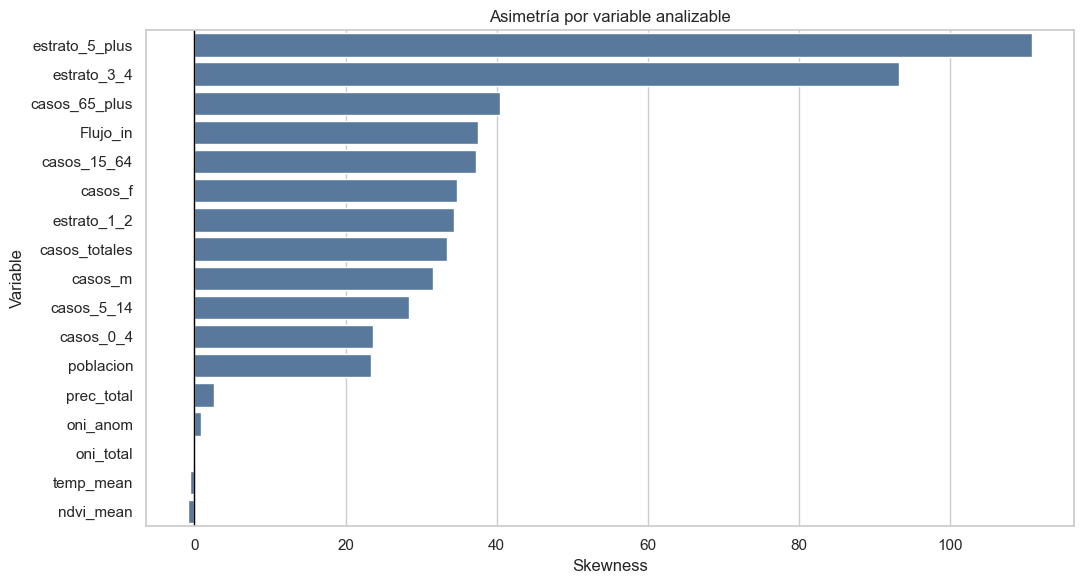

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
asimetria = resumen_global_univariado["skewness"].sort_values(ascending=False)
sns.barplot(x=asimetria.values, y=asimetria.index, color=PALETTE["epidemiologica"], ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Asimetría por variable analizable")
ax.set_xlabel("Skewness")
ax.set_ylabel("Variable")
plt.tight_layout()
fig.savefig(PANORAMA_PATH / "skewness_variables_analizables.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Variable epidemiológica principal: `casos_totales`

El notebook anterior estableció que `casos_totales` tiene alta asimetría, alrededor de 60% de ceros y un Q95 cercano a 18 casos. Aquí se profundiza en la forma de la distribución y en la comparación entre escala original y transformación `log1p`, sin repetir la validación global ya realizada.


### casos_totales

**Rol:** Variable epidemiológica principal

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_totales,int64,813280,813280,0.000,77.612,0.000,0.000,0.000,1.844,0.000,0.000,6.000,1426.000,15.241,33.370,1811.974,543


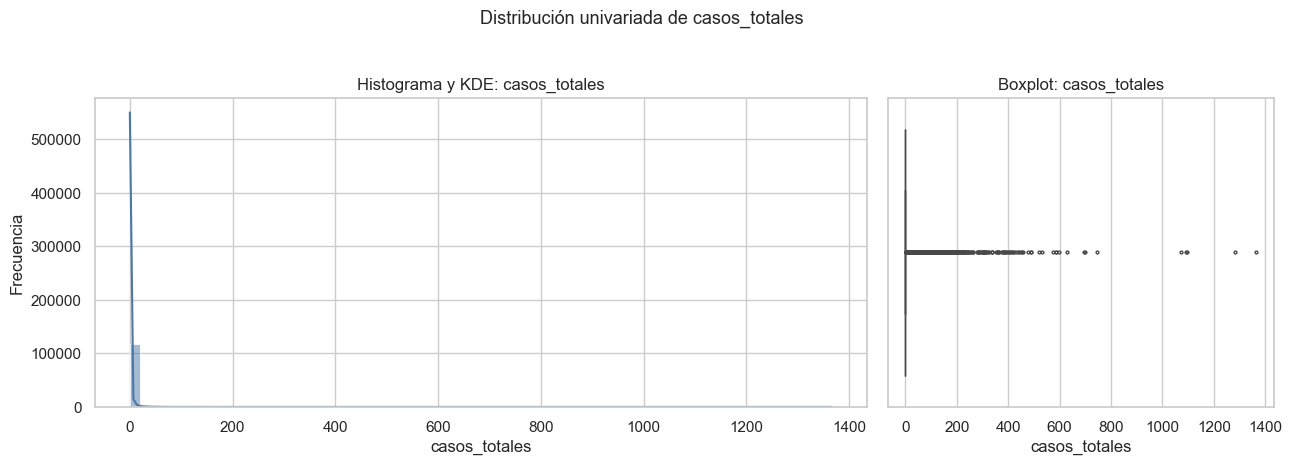

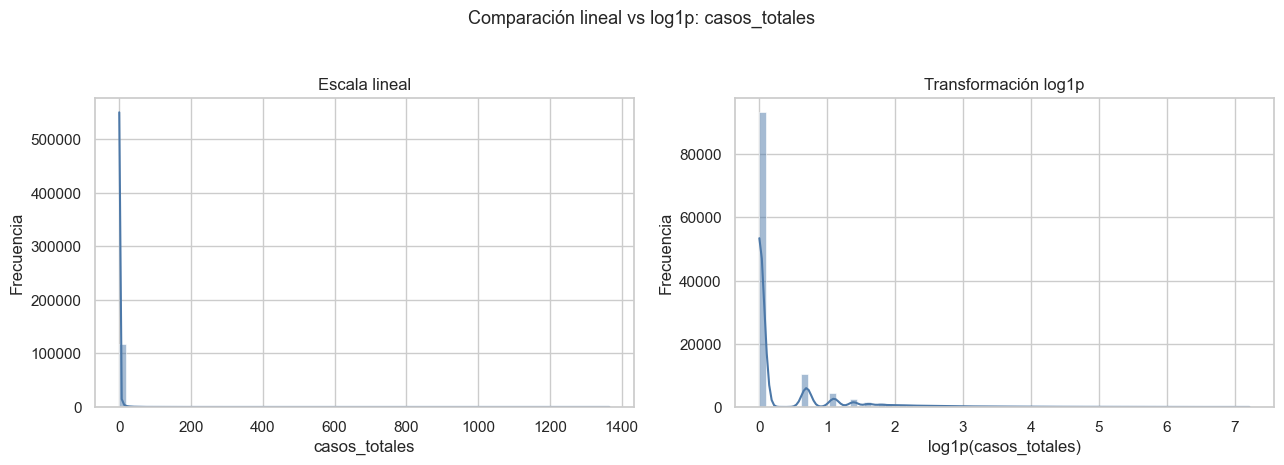

**casos_totales** (Entero (conteo)). Total de casos de dengue reportados en municipio-semana. Rango observado: `0` a `1.43e+03`; mediana `0`; media `1.84`. La masa en cero es dominante (`77.6%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto. Implicación: considerar `log1p(casos_totales)` o enfoques robustos en notebooks posteriores; la variable no debe normalizarse ignorando la masa en cero.

In [19]:
analizar_variable("casos_totales", color=PALETTE["epidemiologica"], bins=70, comparar_log=True)

## 7. Estratificación por edad

Las variables etarias son conteos derivados de la notificación de casos. Su interpretación debe enfocarse en la concentración de casos por grupo y en la presencia de colas, no en compararlas como tasas poblacionales; para eso se necesitarían denominadores por grupo de edad.


In [20]:
variables_edad = variable_groups["Epidemiológicas - edad"]
tabla_resumen(variables_edad)

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_0_4,int64,813280,813280,0.000,94.056,0.000,0.000,0.000,0.162,0.000,0.000,1.000,95.000,1.339,23.651,884.311,85
casos_5_14,int64,813280,813280,0.000,87.469,0.000,0.000,0.000,0.616,0.000,0.000,2.000,421.000,5.097,28.436,1326.234,240
casos_15_64,int64,813280,813280,0.000,82.441,0.000,0.000,0.000,0.979,0.000,0.000,3.000,839.000,8.787,37.289,2115.489,381
casos_65_plus,int64,813280,813280,0.000,95.851,0.000,0.000,0.000,0.087,0.000,0.000,0.000,107.000,0.862,40.416,2810.526,71


### casos_0_4

**Rol:** Estratificación por edad

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_0_4,int64,813280,813280,0.000,94.056,0.000,0.000,0.000,0.162,0.000,0.000,1.000,95.000,1.339,23.651,884.311,85


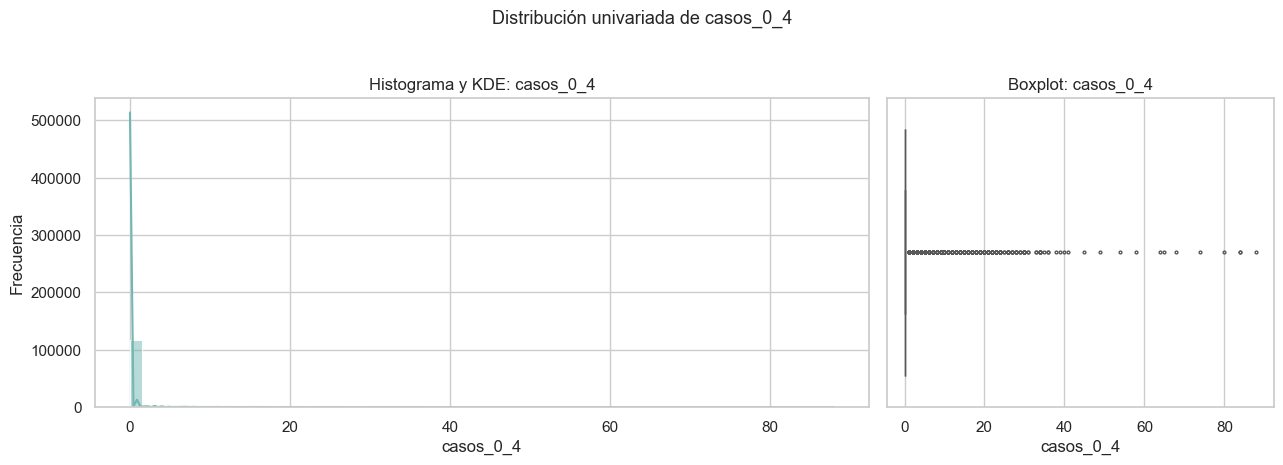

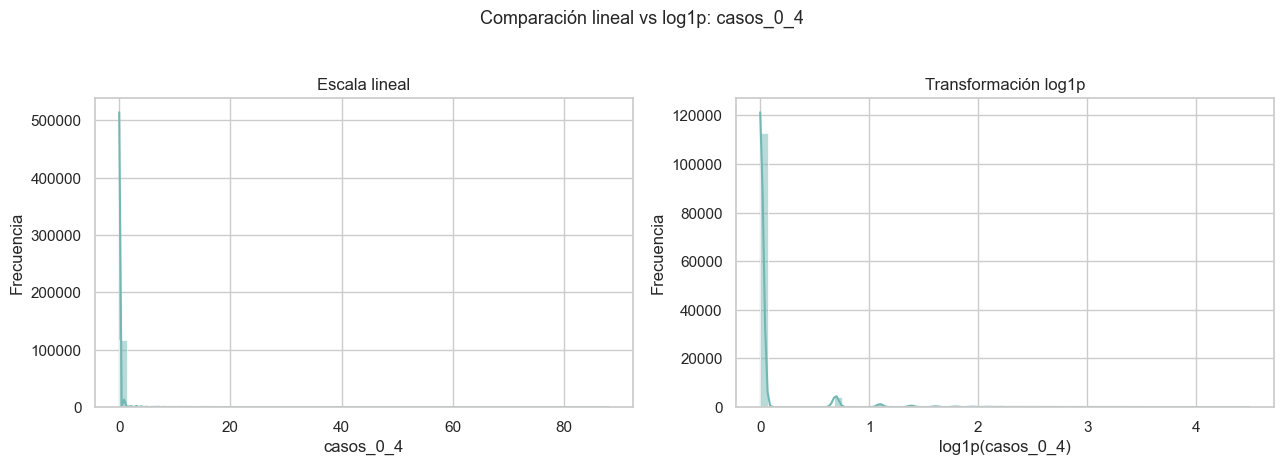

**casos_0_4** (Entero (conteo)). Casos de dengue en edades 0-4 años. Rango observado: `0` a `95`; mediana `0`; media `0.162`. La masa en cero es dominante (`94.1%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

### casos_5_14

**Rol:** Estratificación por edad

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_5_14,int64,813280,813280,0.000,87.469,0.000,0.000,0.000,0.616,0.000,0.000,2.000,421.000,5.097,28.436,1326.234,240


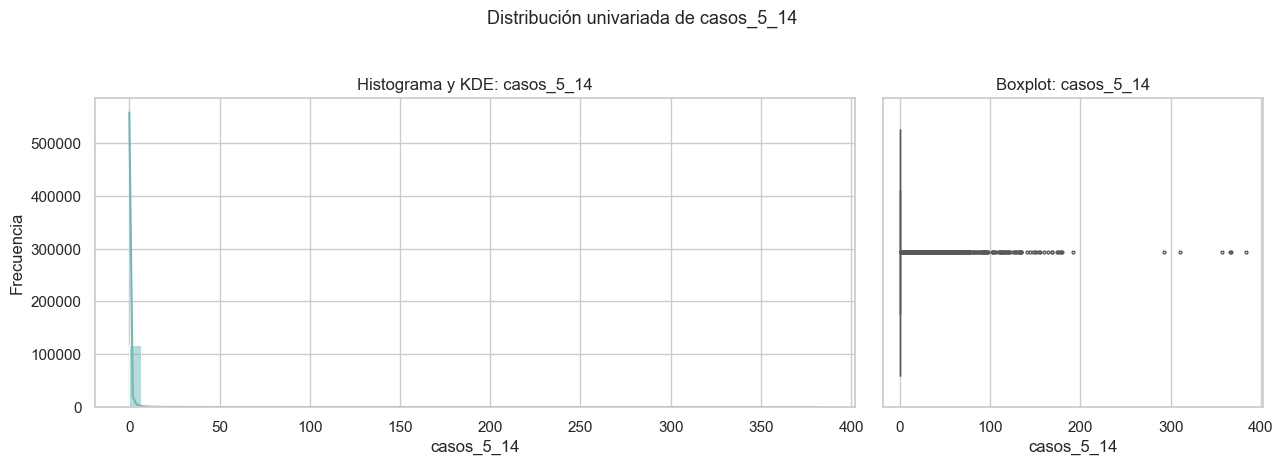

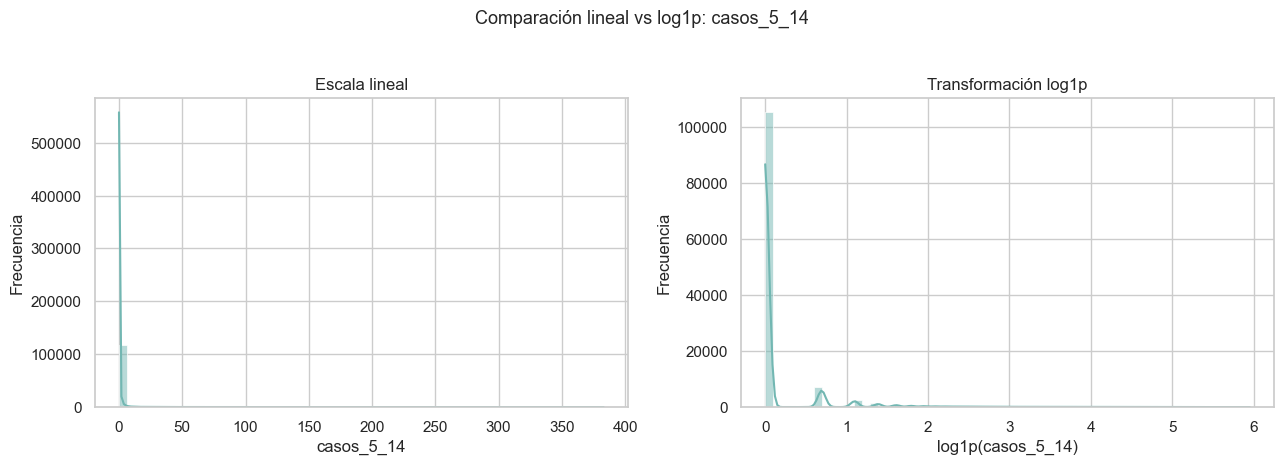

**casos_5_14** (Entero (conteo)). Casos de dengue en edades 5-14 años. Rango observado: `0` a `421`; mediana `0`; media `0.616`. La masa en cero es dominante (`87.5%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

### casos_15_64

**Rol:** Estratificación por edad

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_15_64,int64,813280,813280,0.000,82.441,0.000,0.000,0.000,0.979,0.000,0.000,3.000,839.000,8.787,37.289,2115.489,381


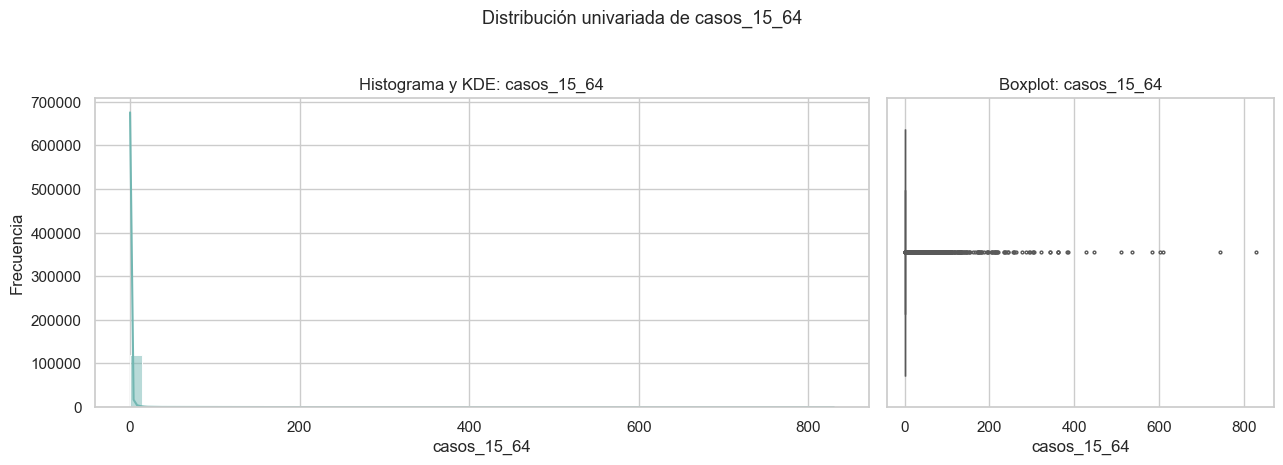

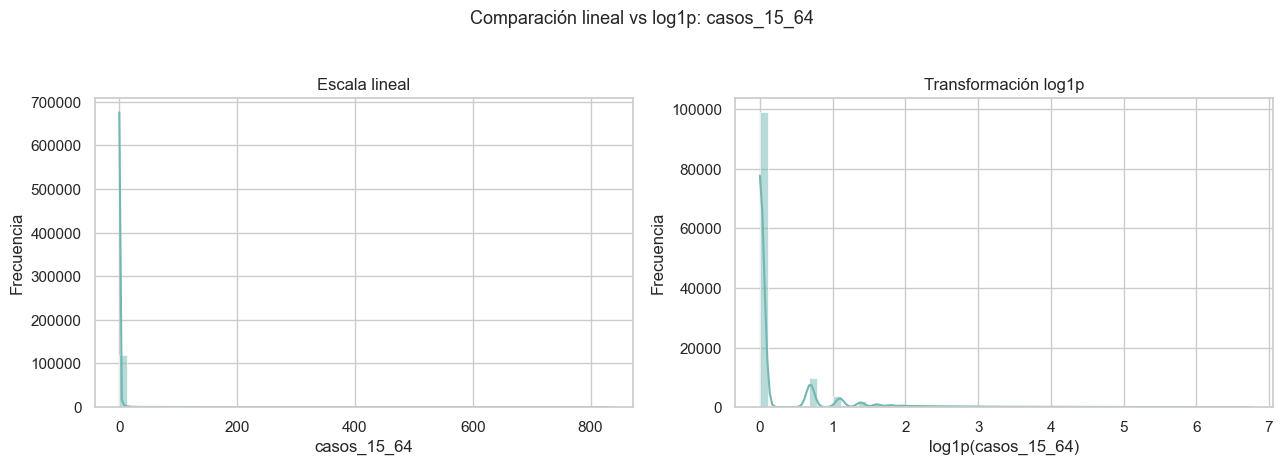

**casos_15_64** (Entero (conteo)). Casos de dengue en edades 15-64 años. Rango observado: `0` a `839`; mediana `0`; media `0.979`. La masa en cero es dominante (`82.4%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

### casos_65_plus

**Rol:** Estratificación por edad

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_65_plus,int64,813280,813280,0.000,95.851,0.000,0.000,0.000,0.087,0.000,0.000,0.000,107.000,0.862,40.416,2810.526,71


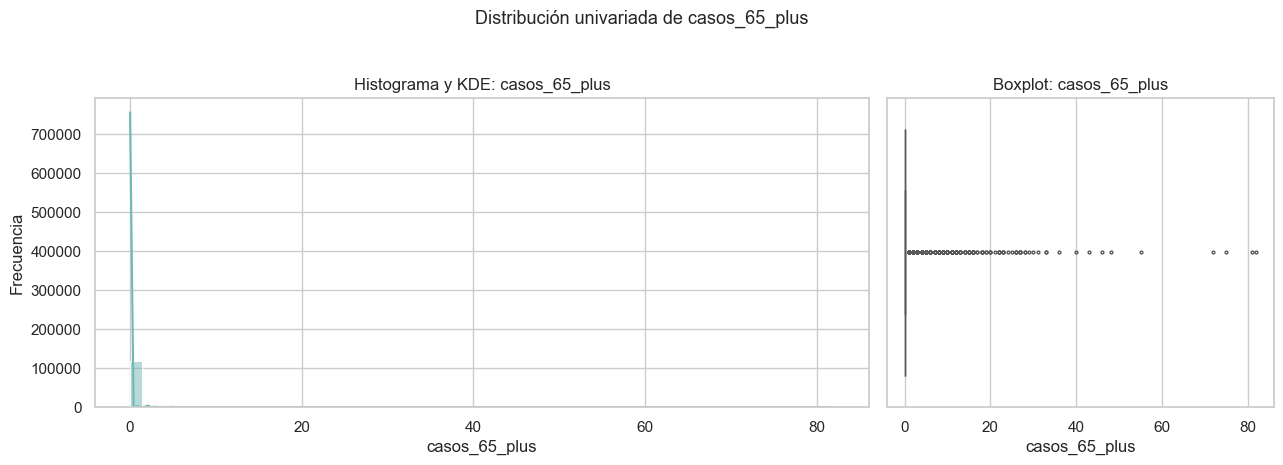

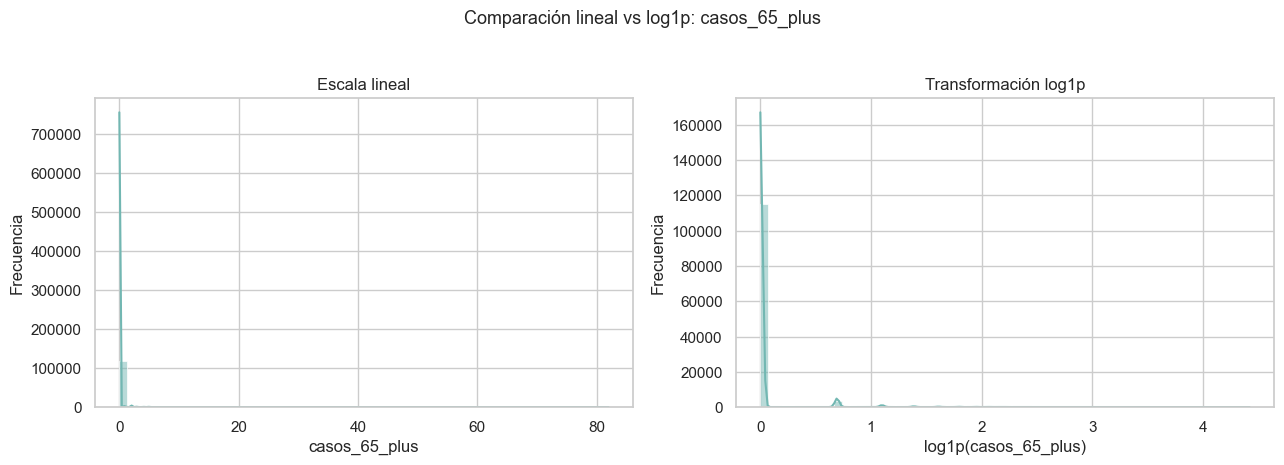

**casos_65_plus** (Entero (conteo)). Casos de dengue en edades 65+ años. Rango observado: `0` a `107`; mediana `0`; media `0.0865`. La masa en cero es dominante (`95.9%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

In [21]:
for variable in variables_edad:
    analizar_variable(variable, color=PALETTE["edad"], bins=60)

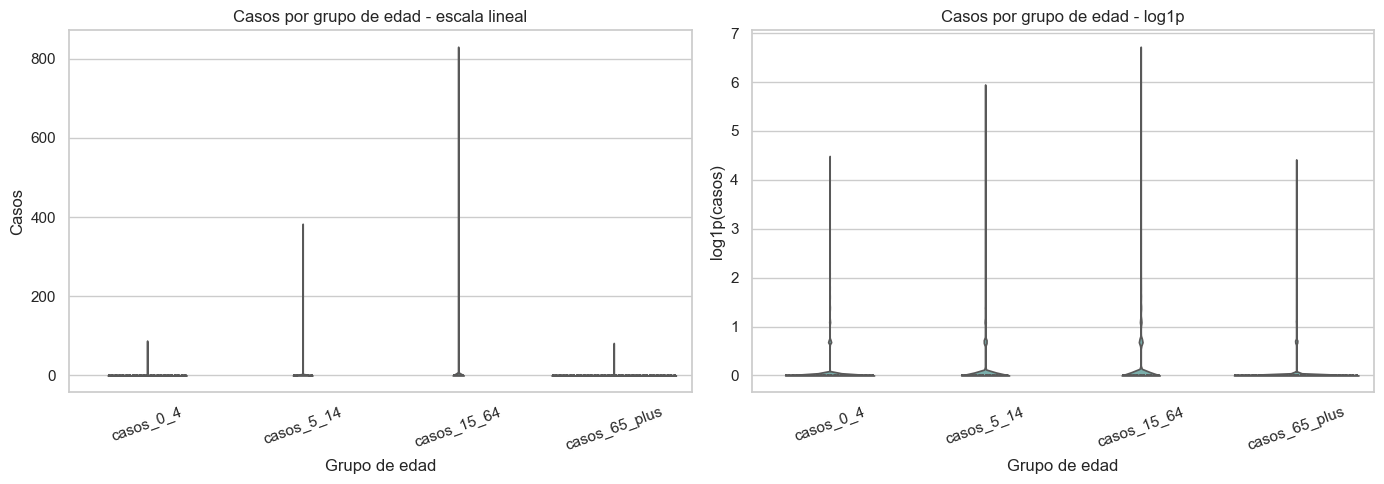

In [22]:
edad_long = (
    df[variables_edad]
    .sample(n=min(PLOT_SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
    .melt(var_name="grupo_edad", value_name="casos")
)
edad_long["log1p_casos"] = np.log1p(edad_long["casos"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=edad_long, x="grupo_edad", y="casos", color=PALETTE["edad"], cut=0, inner="quartile", ax=axes[0])
axes[0].set_title("Casos por grupo de edad - escala lineal")
axes[0].set_xlabel("Grupo de edad")
axes[0].set_ylabel("Casos")
axes[0].tick_params(axis="x", rotation=20)

sns.violinplot(data=edad_long, x="grupo_edad", y="log1p_casos", color=PALETTE["edad"], cut=0, inner="quartile", ax=axes[1])
axes[1].set_title("Casos por grupo de edad - log1p")
axes[1].set_xlabel("Grupo de edad")
axes[1].set_ylabel("log1p(casos)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
fig.savefig(COMPARACIONES_VIOLIN_PATH / "violin_edad_linear_log1p.png", dpi=300, bbox_inches="tight")
plt.show()


**Lectura epidemiológica.** La comparación por edad permite reconocer qué grupos concentran más conteos absolutos, pero no debe leerse como riesgo individual. Una mayor carga en `casos_15_64`, por ejemplo, puede reflejar tanto mayor tamaño poblacional como exposición laboral y movilidad, mientras que los grupos extremos pueden tener menor conteo absoluto por estructura demográfica o diferencias de consulta/notificación.


## 8. Estratificación por sexo

Las variables `casos_m` y `casos_f` permiten describir si los conteos absolutos por sexo presentan distribuciones similares, colas diferentes o concentraciones extremas. Esta sección sigue siendo univariada: no evalúa asociación con edad, municipio ni clima.


In [38]:
variables_sexo = variable_groups["Epidemiológicas - sexo"]
tabla_resumen(variables_sexo)


,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_m,int64,813280,813280,0.000,82.498,0.000,0.000,0.000,0.957,0.000,0.000,3.000,707.000,7.628,31.599,1629.764,346
casos_f,int64,813280,813280,0.000,84.357,0.000,0.000,0.000,0.887,0.000,0.000,3.000,748.000,7.697,34.736,1964.508,344


### casos_m

**Rol:** Estratificación por sexo

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_m,int64,813280,813280,0.000,82.498,0.000,0.000,0.000,0.957,0.000,0.000,3.000,707.000,7.628,31.599,1629.764,346


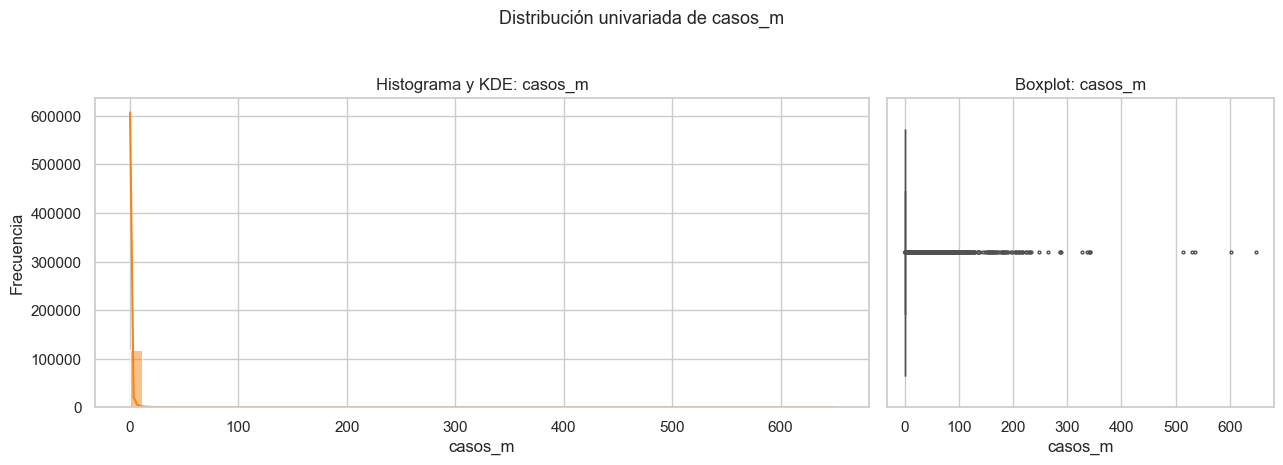

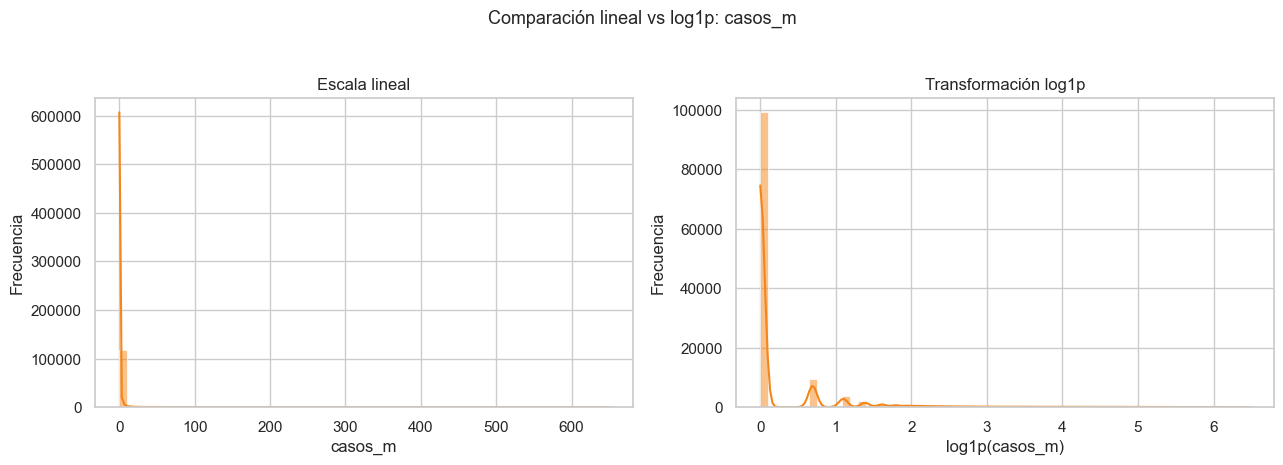

**casos_m** (Entero (conteo)). Casos de dengue reportados en hombres. Rango observado: `0` a `707`; mediana `0`; media `0.957`. La masa en cero es dominante (`82.5%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

### casos_f

**Rol:** Estratificación por sexo

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
casos_f,int64,813280,813280,0.000,84.357,0.000,0.000,0.000,0.887,0.000,0.000,3.000,748.000,7.697,34.736,1964.508,344


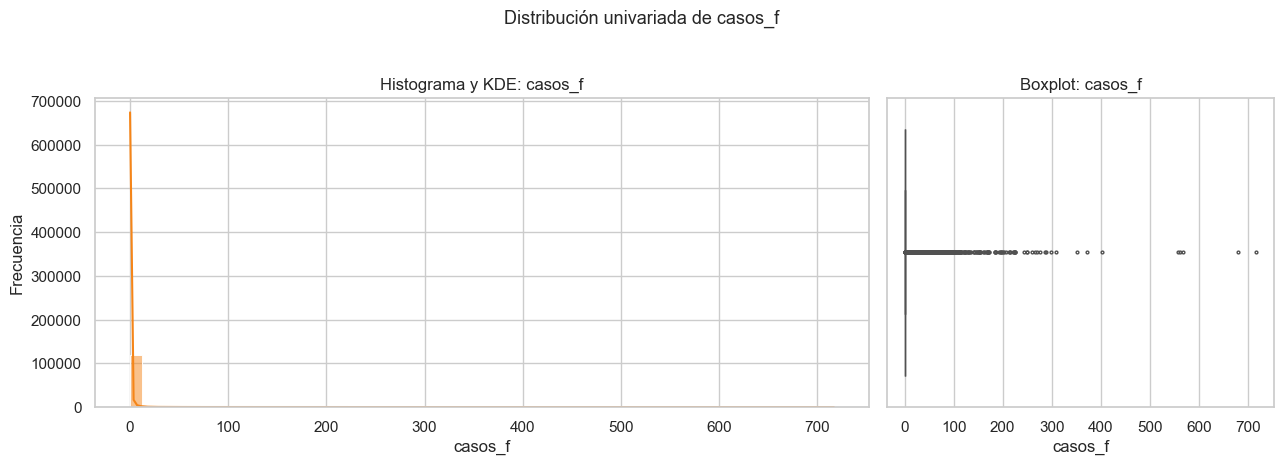

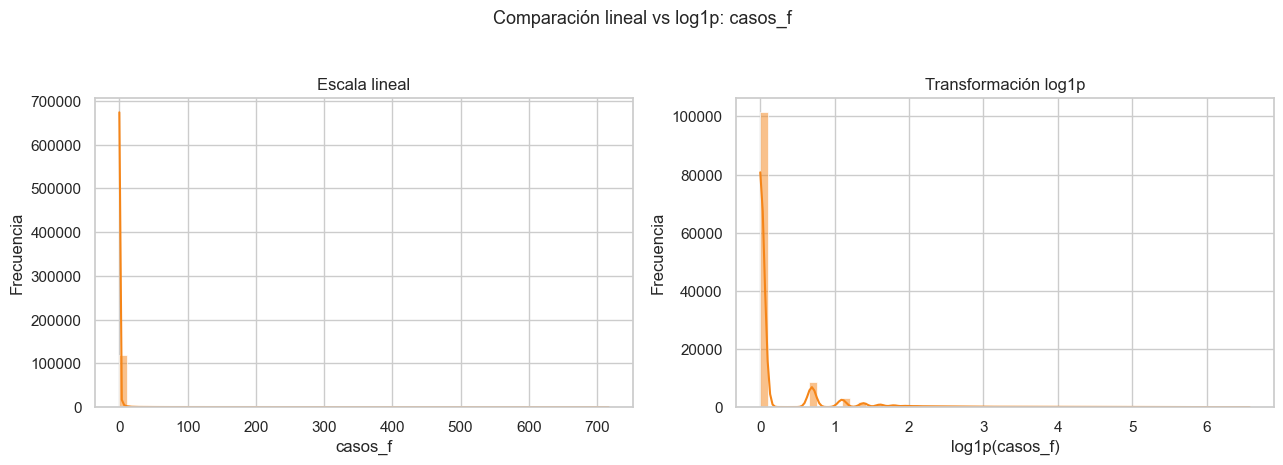

**casos_f** (Entero (conteo)). Casos de dengue reportados en mujeres. Rango observado: `0` a `748`; mediana `0`; media `0.887`. La masa en cero es dominante (`84.4%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

In [39]:
for variable in variables_sexo:
    analizar_variable(variable, color=PALETTE["sexo"], bins=60)


C:\Users\camil\AppData\Local\Temp\ipykernel_8684\488190439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sexo_long, x="sexo", y="casos", palette=["#F58518", "#ECA154"], cut=0, inner="quartile", ax=axes[0])
C:\Users\camil\AppData\Local\Temp\ipykernel_8684\488190439.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sexo_long, x="sexo", y="log1p_casos", palette=["#F58518", "#ECA154"], cut=0, inner="quartile", ax=axes[1])


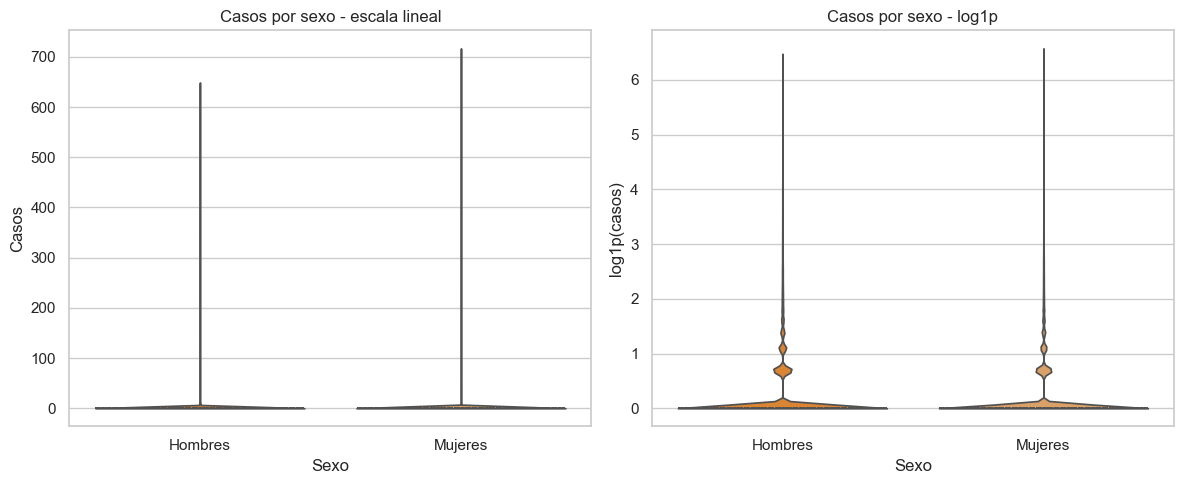

In [40]:
sexo_long = (
    df[variables_sexo]
    .sample(n=min(PLOT_SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
    .rename(columns={"casos_m": "Hombres", "casos_f": "Mujeres"})
    .melt(var_name="sexo", value_name="casos")
)
sexo_long["log1p_casos"] = np.log1p(sexo_long["casos"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=sexo_long, x="sexo", y="casos", palette=["#F58518", "#ECA154"], cut=0, inner="quartile", ax=axes[0])
axes[0].set_title("Casos por sexo - escala lineal")
axes[0].set_xlabel("Sexo")
axes[0].set_ylabel("Casos")

sns.violinplot(data=sexo_long, x="sexo", y="log1p_casos", palette=["#F58518", "#ECA154"], cut=0, inner="quartile", ax=axes[1])
axes[1].set_title("Casos por sexo - log1p")
axes[1].set_xlabel("Sexo")
axes[1].set_ylabel("log1p(casos)")

plt.tight_layout()
fig.savefig(COMPARACIONES_VIOLIN_PATH / "violin_sexo_linear_log1p.png", dpi=300, bbox_inches="tight")
plt.show()


**Lectura epidemiológica.** Distribuciones parecidas entre hombres y mujeres sugieren que la carga agregada por sexo no difiere de forma dramática en conteos absolutos. Diferencias en colas altas pueden deberse a brotes urbanos o a patrones de exposición y consulta, pero requieren análisis estratificado posterior antes de interpretarse como desigualdad de riesgo.


## 9. Estratificación socioeconómica

Las variables de estrato representan registros parciales por categoría socioeconómica. Por tanto, su distribución debe leerse como cobertura observada de notificación por estrato y no como suma exhaustiva de `casos_totales`.


In [41]:
variables_estrato = variable_groups["Estratificación socioeconómica"]
tabla_resumen(variables_estrato)


,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
estrato_1_2,int64,813280,813280,0.000,90.311,0.000,0.000,0.000,0.729,0.000,0.000,2.000,658.000,7.435,34.398,1826.326,343
estrato_3_4,int64,813280,813280,0.000,98.454,0.000,0.000,0.000,0.132,0.000,0.000,0.000,684.000,3.943,93.154,11576.116,199
estrato_5_plus,int64,813280,813280,0.000,99.676,0.000,0.000,0.000,0.010,0.000,0.000,0.000,93.000,0.423,110.776,16173.295,50


### estrato_1_2

**Rol:** Estratificación socioeconómica parcial

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
estrato_1_2,int64,813280,813280,0.000,90.311,0.000,0.000,0.000,0.729,0.000,0.000,2.000,658.000,7.435,34.398,1826.326,343


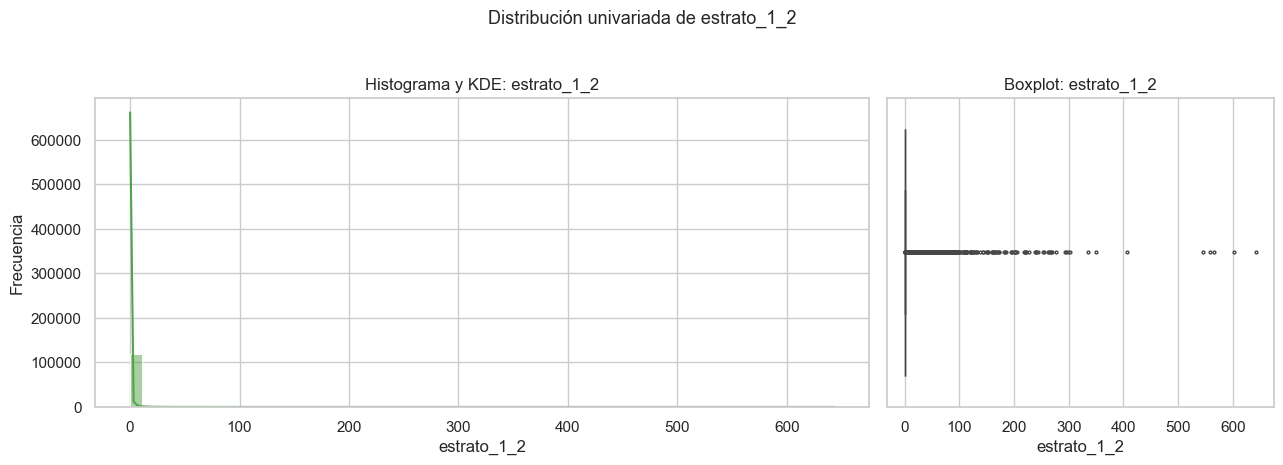

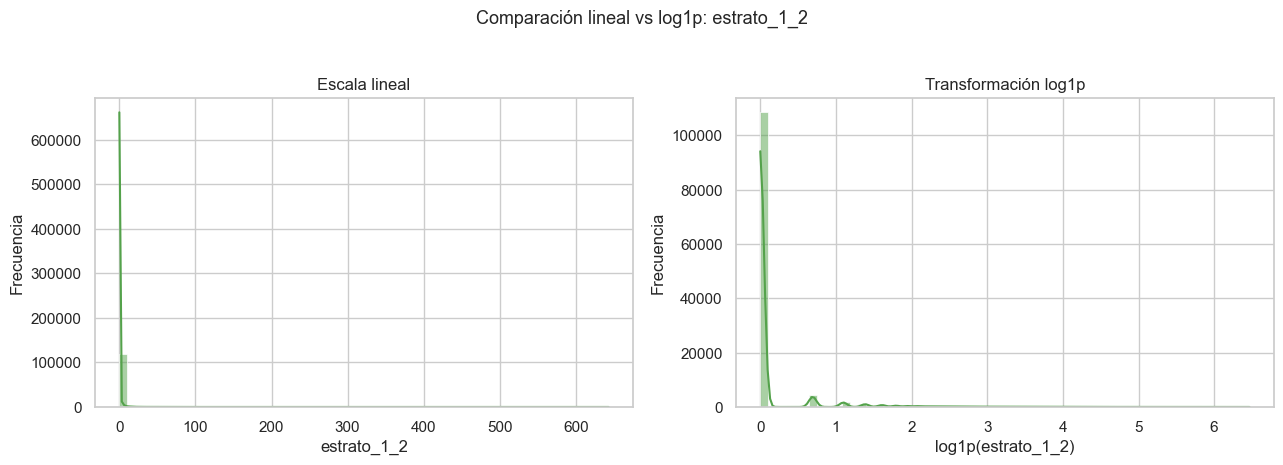

**estrato_1_2** (Entero (conteo)). Casos con registro en estratos socioeconómicos 1-2; no necesariamente suma casos_totales. Rango observado: `0` a `658`; mediana `0`; media `0.729`. La masa en cero es dominante (`90.3%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

### estrato_3_4

**Rol:** Estratificación socioeconómica parcial

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
estrato_3_4,int64,813280,813280,0.000,98.454,0.000,0.000,0.000,0.132,0.000,0.000,0.000,684.000,3.943,93.154,11576.116,199


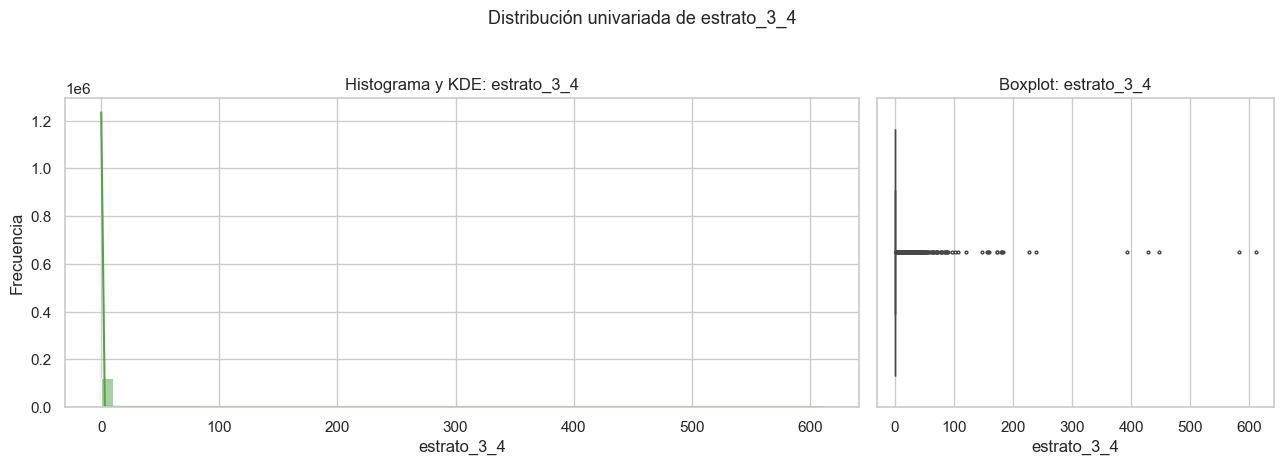

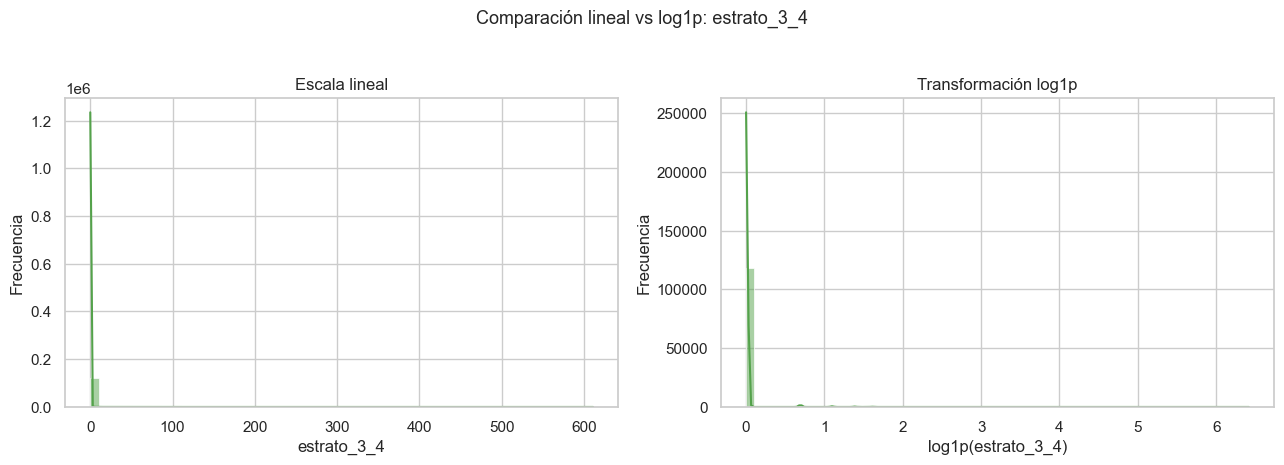

**estrato_3_4** (Entero (conteo)). Casos con registro en estratos socioeconómicos 3-4; no necesariamente suma casos_totales. Rango observado: `0` a `684`; mediana `0`; media `0.132`. La masa en cero es dominante (`98.5%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

### estrato_5_plus

**Rol:** Estratificación socioeconómica parcial

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
estrato_5_plus,int64,813280,813280,0.000,99.676,0.000,0.000,0.000,0.010,0.000,0.000,0.000,93.000,0.423,110.776,16173.295,50


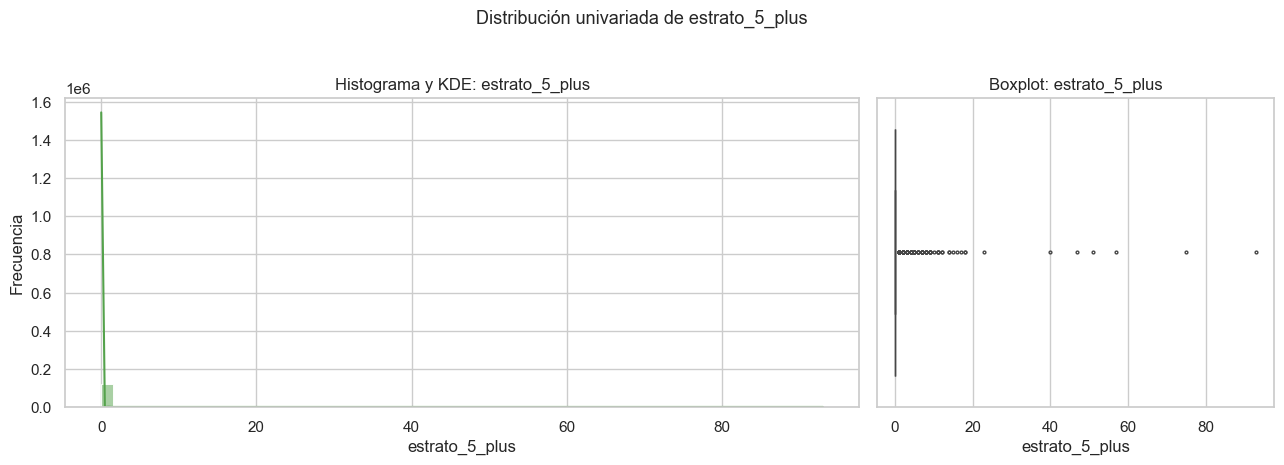

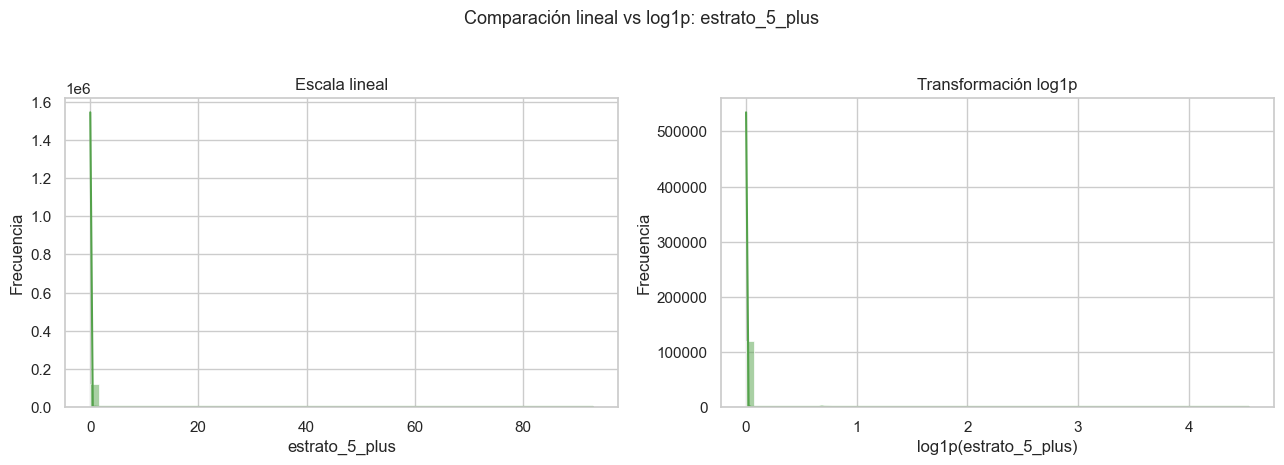

**estrato_5_plus** (Entero (conteo)). Casos con registro en estratos socioeconómicos 5+; no necesariamente suma casos_totales. Rango observado: `0` a `93`; mediana `0`; media `0.0101`. La masa en cero es dominante (`99.7%`), patrón compatible con muchas semanas-municipio sin reporte de casos o sin registro en esa dimensión. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto.

In [42]:
for variable in variables_estrato:
    analizar_variable(variable, color=PALETTE["estrato"], bins=60)


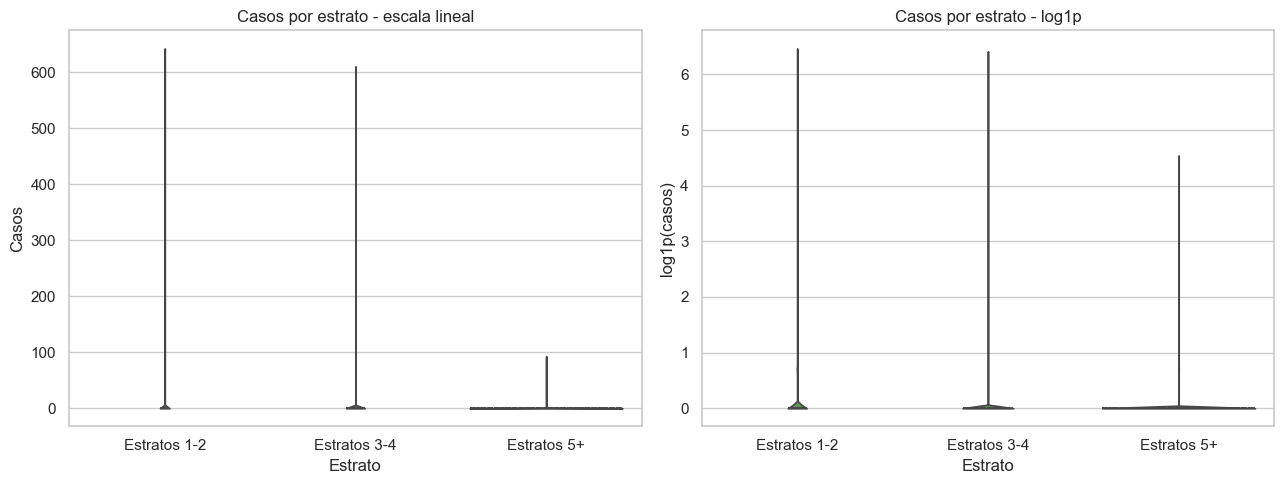

In [43]:
estrato_long = (
    df[variables_estrato]
    .sample(n=min(PLOT_SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
    .rename(columns={
        "estrato_1_2": "Estratos 1-2",
        "estrato_3_4": "Estratos 3-4",
        "estrato_5_plus": "Estratos 5+",
    })
    .melt(var_name="estrato", value_name="casos")
)
estrato_long["log1p_casos"] = np.log1p(estrato_long["casos"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(data=estrato_long, x="estrato", y="casos", color=PALETTE["estrato"], cut=0, inner="quartile", ax=axes[0])
axes[0].set_title("Casos por estrato - escala lineal")
axes[0].set_xlabel("Estrato")
axes[0].set_ylabel("Casos")

sns.violinplot(data=estrato_long, x="estrato", y="log1p_casos", color=PALETTE["estrato"], cut=0, inner="quartile", ax=axes[1])
axes[1].set_title("Casos por estrato - log1p")
axes[1].set_xlabel("Estrato")
axes[1].set_ylabel("log1p(casos)")

plt.tight_layout()
fig.savefig(COMPARACIONES_VIOLIN_PATH / "violin_estrato_linear_log1p.png", dpi=300, bbox_inches="tight")
plt.show()


**Lectura epidemiológica.** Si `estrato_1_2` concentra la gran mayoría de casos con estrato registrado, el patrón es consistente con vulnerabilidad socioeconómica, mayor exposición ambiental o sesgos de cobertura del sistema de notificación. Como estas variables tienen cobertura parcial, el próximo paso no debe ser imputar mecánicamente estratos faltantes como cero epidemiológico sin documentar el mecanismo de registro.


## 10. Variables climáticas: temperatura y precipitación

`temp_mean` y `prec_total` describen condiciones climáticas semanales, pero tienen niveles de faltantes muy distintos. La temperatura tiene cobertura limitada y la precipitación combina semanas secas, acumulados moderados y eventos extremos.


In [48]:
variables_clima = variable_groups["Climáticas"]
tabla_resumen(variables_clima)


,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
temp_mean,float64,813280,179678,77.907,0.000,2.583,12.712,18.086,22.389,23.700,27.132,29.364,34.389,5.569,-0.572,-0.550,41618
prec_total,float64,813280,532030,34.582,16.063,0.000,0.000,5.000,43.830,25.300,62.000,150.300,1053.000,55.414,2.646,12.451,5055


### temp_mean

**Rol:** Variable climática

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
temp_mean,float64,813280,179678,77.907,0.000,2.583,12.712,18.086,22.389,23.700,27.132,29.364,34.389,5.569,-0.572,-0.550,41618


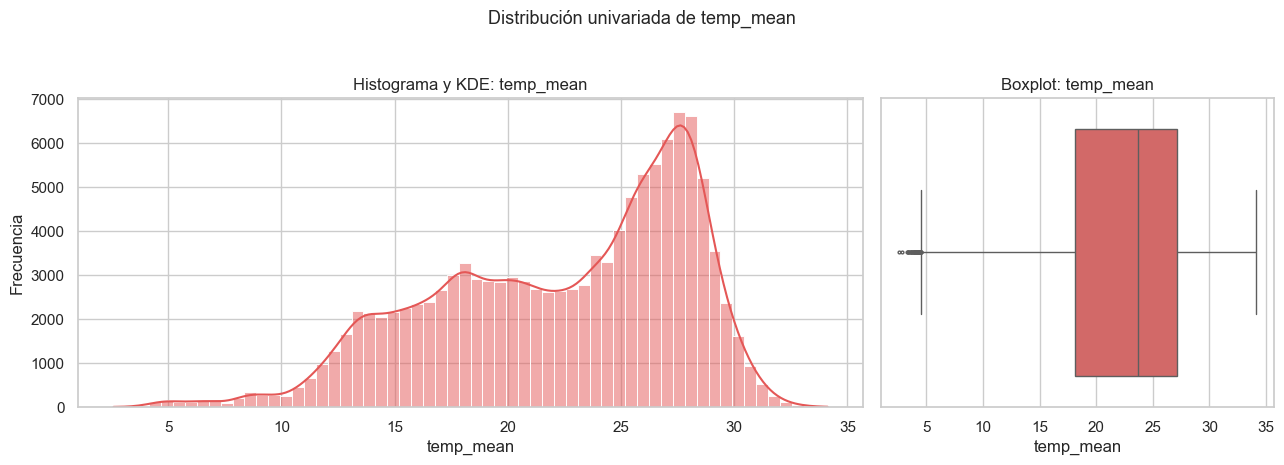

**temp_mean** (Decimal (grados Celsius)). Temperatura media semanal disponible para una fracción del panel. Rango observado: `2.58` a `34.4`; mediana `23.7`; media `22.4`. Presenta faltantes altos (`77.9%`), por lo que debe tratarse explícitamente en imputación o análisis de sensibilidad. La asimetría no domina la forma de la distribución, por lo que la escala original es interpretable para descripción univariada. Implicación: su alto faltante impide asumir representatividad completa del panel climático sin imputación o restricción de muestra.

### prec_total

**Rol:** Variable climática

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
prec_total,float64,813280,532030,34.582,16.063,0.000,0.000,5.000,43.830,25.300,62.000,150.300,1053.000,55.414,2.646,12.451,5055


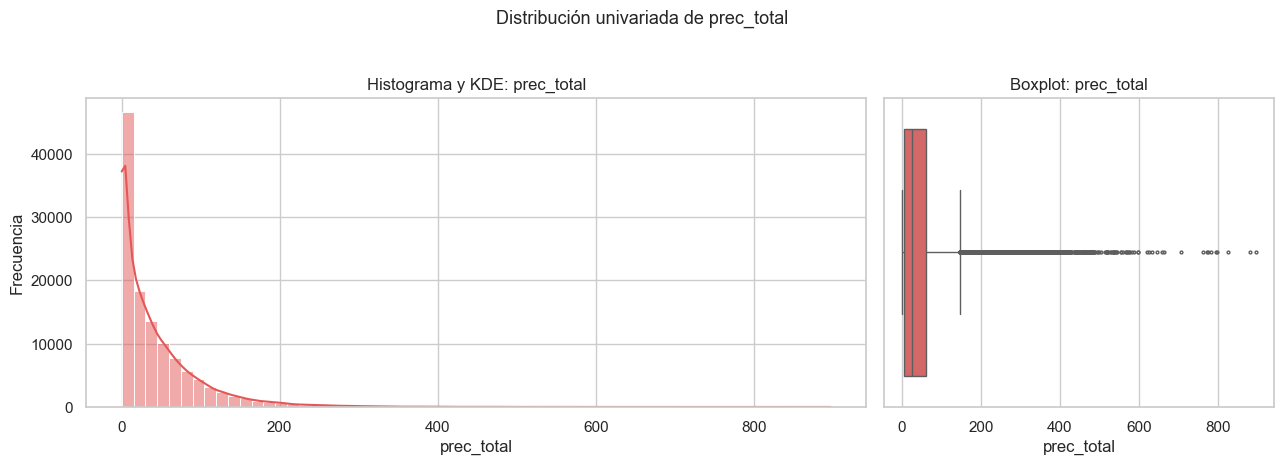

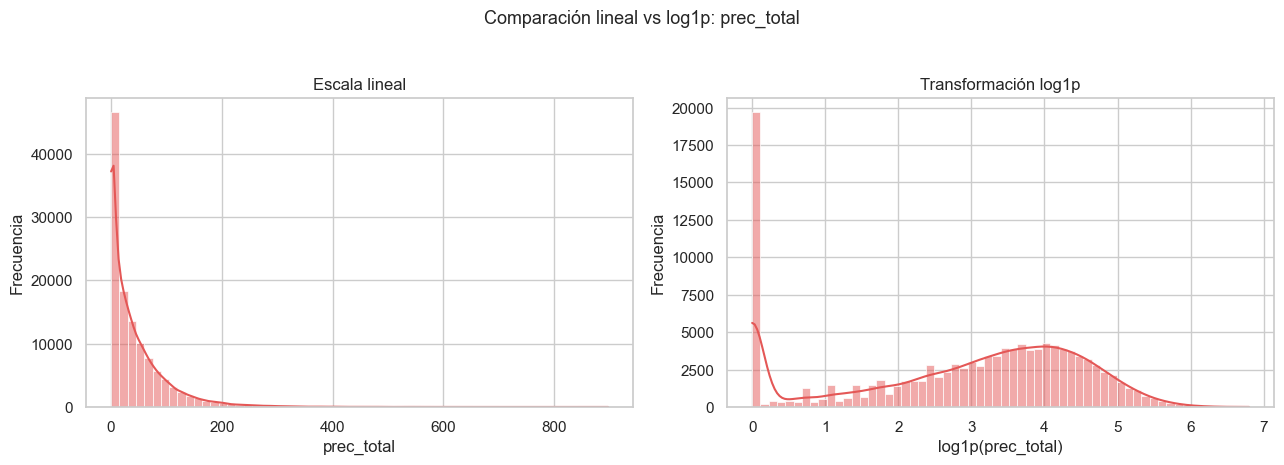

**prec_total** (Decimal (mm)). Precipitación total semanal acumulada. Rango observado: `0` a `1.05e+03`; mediana `25.3`; media `43.8`. Presenta faltantes altos (`34.6%`), por lo que debe tratarse explícitamente en imputación o análisis de sensibilidad. Incluye ceros (`16.1%`), que deben preservarse porque suelen tener significado epidemiológico o ambiental. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto. Implicación: la precipitación combina ceros reales y valores extremos; conviene evaluar imputación y posible transformación antes de comparaciones multivariadas.

In [30]:
for variable in variables_clima:
    analizar_variable(variable, color=PALETTE["climatica"], bins=60)


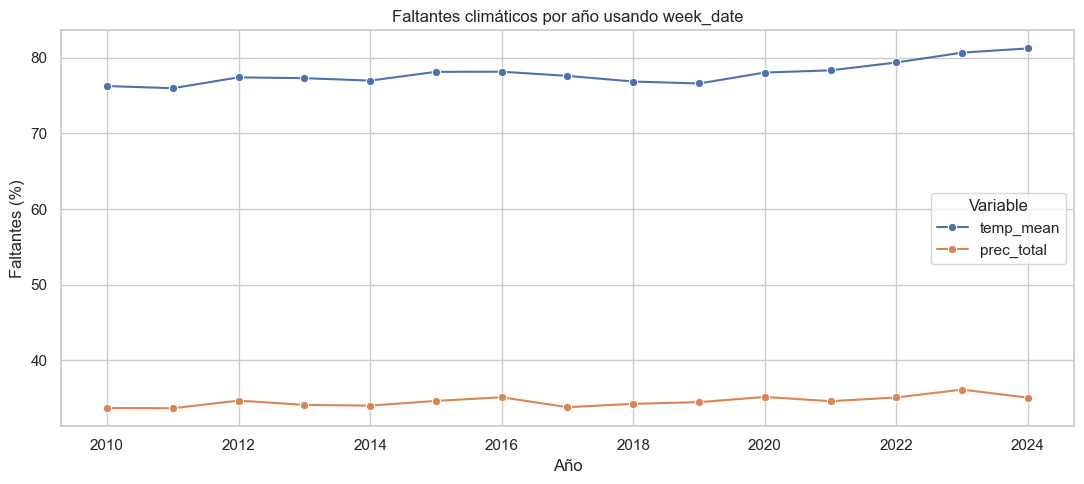

In [31]:
faltantes_clima_anual = (
    df.assign(anio=df["week_date"].dt.year)
    .groupby("anio")[variables_clima]
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index()
    .melt(id_vars="anio", var_name="variable", value_name="faltantes_%")
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=faltantes_clima_anual, x="anio", y="faltantes_%", hue="variable", marker="o", ax=ax)
ax.set_title("Faltantes climáticos por año usando week_date")
ax.set_xlabel("Año")
ax.set_ylabel("Faltantes (%)")
ax.legend(title="Variable")
plt.tight_layout()
fig.savefig(FALTANTES_PATH / "faltantes_clima_por_anio_week_date.png", dpi=300, bbox_inches="tight")
plt.show()


**Lectura epidemiológica.** Las variables climáticas no solo importan por su distribución, sino por su disponibilidad temporal. Un alto faltante en `temp_mean` puede sesgar cualquier comparación si la ausencia se concentra en años, regiones o municipios específicos. `prec_total`, por su parte, requiere distinguir ceros plausibles de precipitación frente a ausencias de medición ya codificadas como `NaN`.


## 11. Variables ambientales y macroclimáticas

`ndvi_mean` resume cobertura vegetal y `oni_anom`/`oni_total` capturan variabilidad oceánica de gran escala. Estas variables no son conteos epidemiológicos; por tanto, una masa en cero o una cola extrema tiene una interpretación distinta a la de los casos.


In [32]:
variables_ambientales = variable_groups["Ambientales y macroclima"]
tabla_resumen(variables_ambientales)


,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
ndvi_mean,float64,813280,812498,0.096,0.000,0.066,0.390,0.550,0.624,0.645,0.717,0.788,0.886,0.123,-0.779,0.352,187020
oni_anom,float64,813280,813280,0.000,0.512,-1.640,-1.080,-0.600,0.052,-0.140,0.570,1.920,2.750,0.900,0.820,0.514,131
oni_total,float64,813280,813280,0.000,0.000,25.020,25.580,26.300,27.053,27.100,27.750,28.820,29.260,1.009,0.129,-0.746,140


### ndvi_mean

**Rol:** Variable ambiental

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
ndvi_mean,float64,813280,812498,0.096,0.000,0.066,0.390,0.550,0.624,0.645,0.717,0.788,0.886,0.123,-0.779,0.352,187020


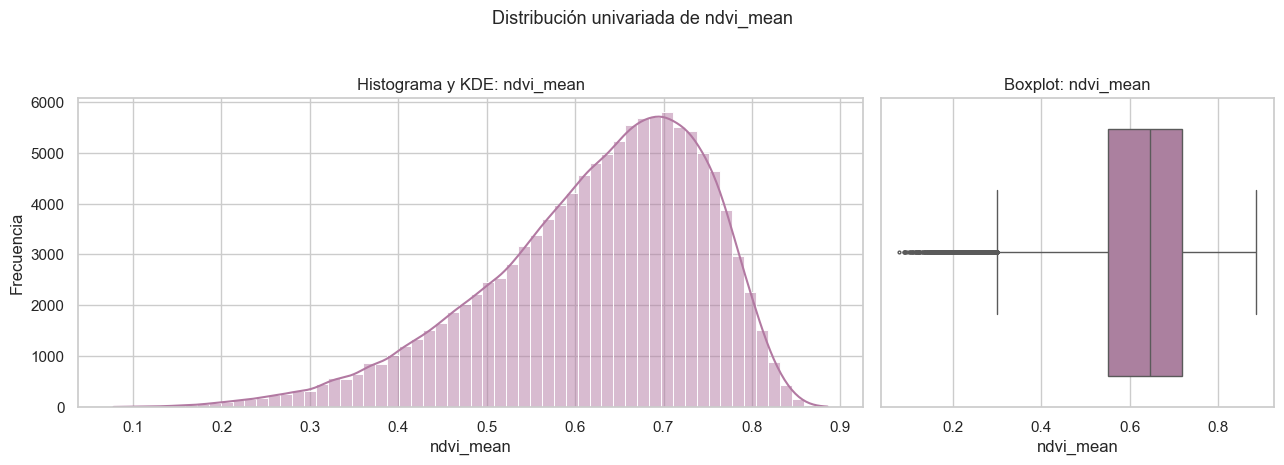

**ndvi_mean** (Decimal (índice)). Índice de vegetación de diferencia normalizada promedio. Rango observado: `0.0659` a `0.886`; mediana `0.645`; media `0.624`. Tiene faltantes bajos/moderados (`0.1%`), suficientes para documentar antes de cualquier transformación. La asimetría no domina la forma de la distribución, por lo que la escala original es interpretable para descripción univariada.

### oni_anom

**Rol:** Variable climática oceánica

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
oni_anom,float64,813280,813280,0.000,0.512,-1.640,-1.080,-0.600,0.052,-0.140,0.570,1.920,2.750,0.900,0.820,0.514,131


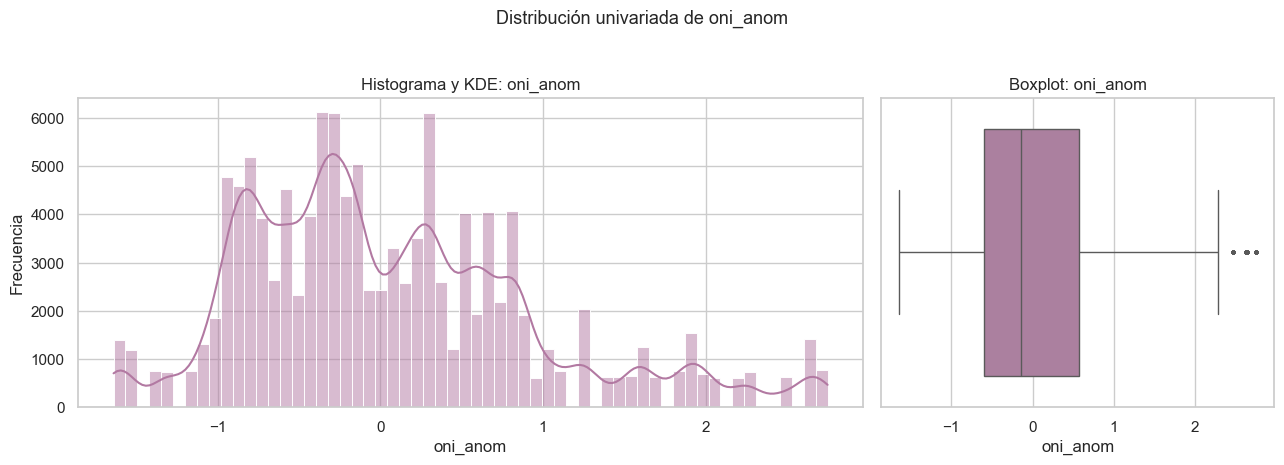

**oni_anom** (Decimal (anomalía)). Anomalía del Oceanic Niño Index, proxy de condiciones El Niño/La Niña. Rango observado: `-1.64` a `2.75`; mediana `-0.14`; media `0.0516`. Incluye ceros (`0.5%`), que deben preservarse porque suelen tener significado epidemiológico o ambiental. La asimetría no domina la forma de la distribución, por lo que la escala original es interpretable para descripción univariada.

### oni_total

**Rol:** Variable climática oceánica

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
oni_total,float64,813280,813280,0.000,0.000,25.020,25.580,26.300,27.053,27.100,27.750,28.820,29.260,1.009,0.129,-0.746,140


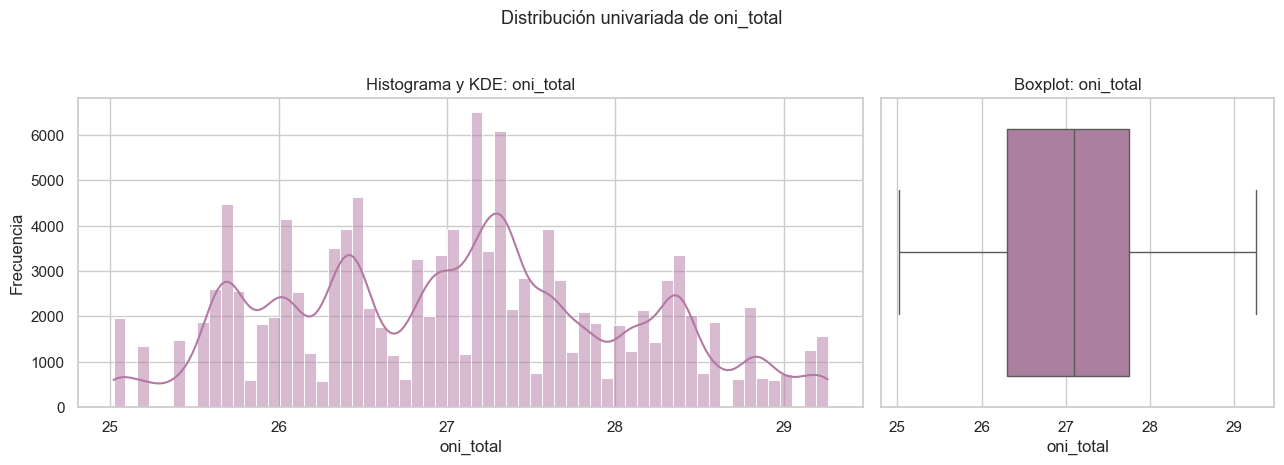

**oni_total** (Decimal (índice)). Valor absoluto del índice oceánico asociado al ONI. Rango observado: `25` a `29.3`; mediana `27.1`; media `27.1`. La asimetría no domina la forma de la distribución, por lo que la escala original es interpretable para descripción univariada.

In [33]:
for variable in variables_ambientales:
    analizar_variable(variable, color=PALETTE["ambiental"], bins=60, comparar_log=False)


**Lectura epidemiológica.** `ndvi_mean` ayuda a diferenciar contextos ecológicos municipales, pero no debe interpretarse como exposición directa al vector sin considerar rezagos y estacionalidad. `oni_anom` admite valores negativos y positivos, por lo que transformaciones logarítmicas no son apropiadas; su utilidad posterior estará más asociada con fases climáticas y temporalidad que con colas de distribución.


## 12. Variables demográficas y de movilidad

`poblacion` y `Flujo_in` suelen ser variables muy asimétricas porque pocos municipios concentran gran tamaño poblacional o alta atracción de movilidad. En análisis epidemiológico, estas variables son candidatas naturales para transformaciones, estandarización o uso como denominadores/contexto.


In [34]:
variables_demografia_flujo = variable_groups["Demográficas y flujo"]
tabla_resumen(variables_demografia_flujo)


,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
poblacion,int64,813280,813280,0.000,0.000,766.000,2593.600,6679.250,41809.759,12383.500,25478.000,116769.900,7149540.000,250308.589,23.314,632.236,1024
Flujo_in,float64,813280,812498,0.096,0.256,0.000,0.041,0.143,1.841,0.351,0.931,5.191,1337.560,13.269,37.529,2215.192,804723


### poblacion

**Rol:** Variable demográfica

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
poblacion,int64,813280,813280,0.000,0.000,766.000,2593.600,6679.250,41809.759,12383.500,25478.000,116769.900,7149540.000,250308.589,23.314,632.236,1024


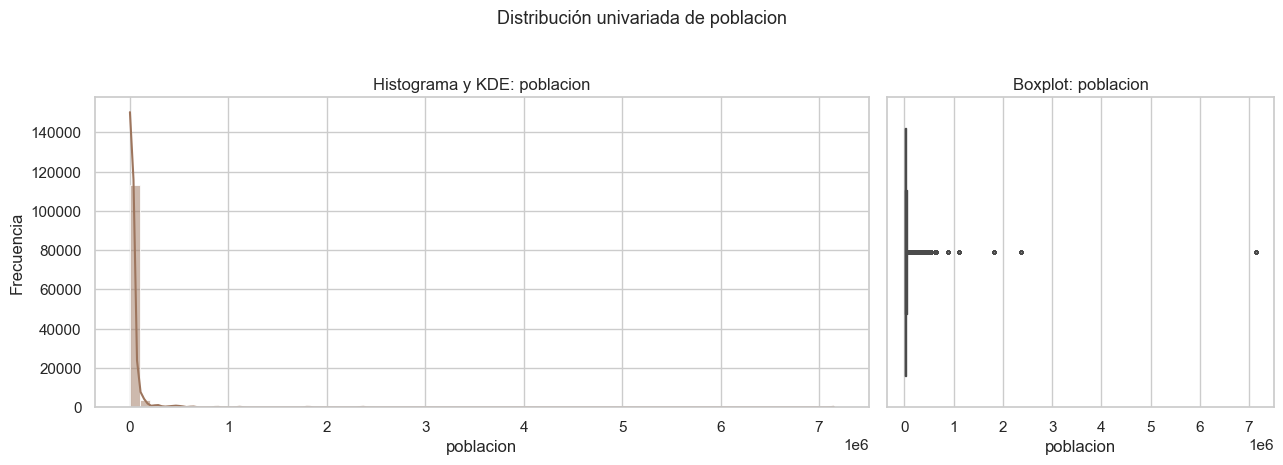

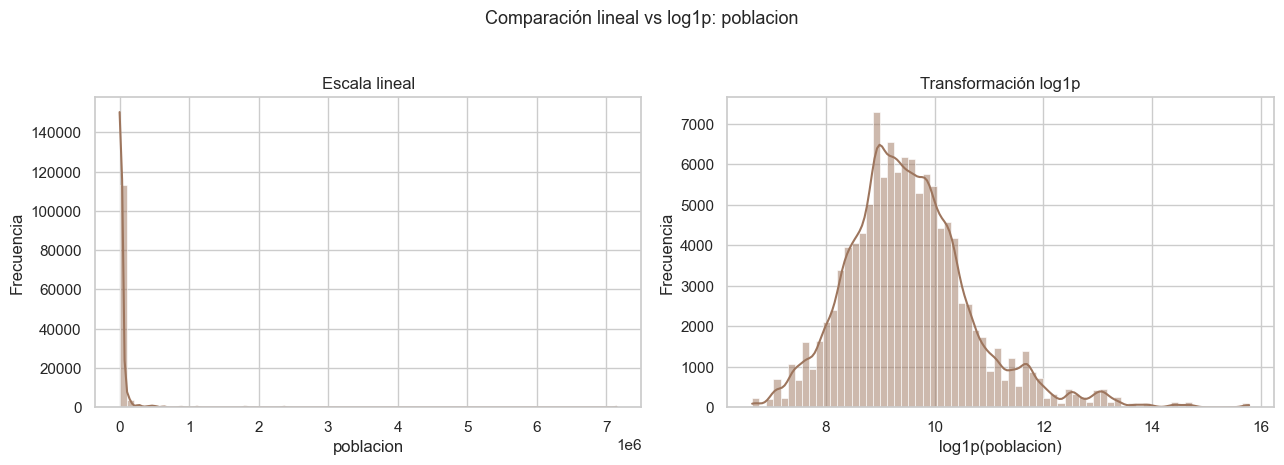

**poblacion** (Entero (conteo)). Población municipal anual asociada al registro municipio-semana. Rango observado: `766` a `7.15e+06`; mediana `1.24e+04`; media `4.18e+04`. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto. Implicación: la escala poblacional puede dominar análisis posteriores; tasas o estandarización serán preferibles a conteos crudos para comparaciones municipales.

### Flujo_in

**Rol:** Variable de movilidad

,tipo_pandas,n,n_no_nulos,faltantes_%,ceros_%,min,q05,q25,media,mediana,q75,q95,max,std,skewness,kurtosis,valores_unicos
Flujo_in,float64,813280,812498,0.096,0.256,0.000,0.041,0.143,1.841,0.351,0.931,5.191,1337.560,13.269,37.529,2215.192,804723


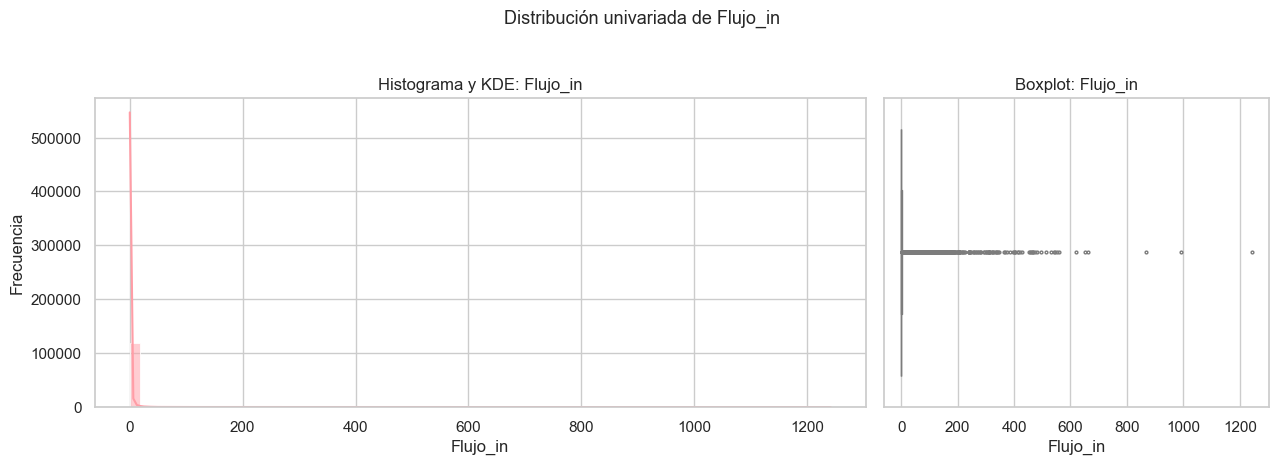

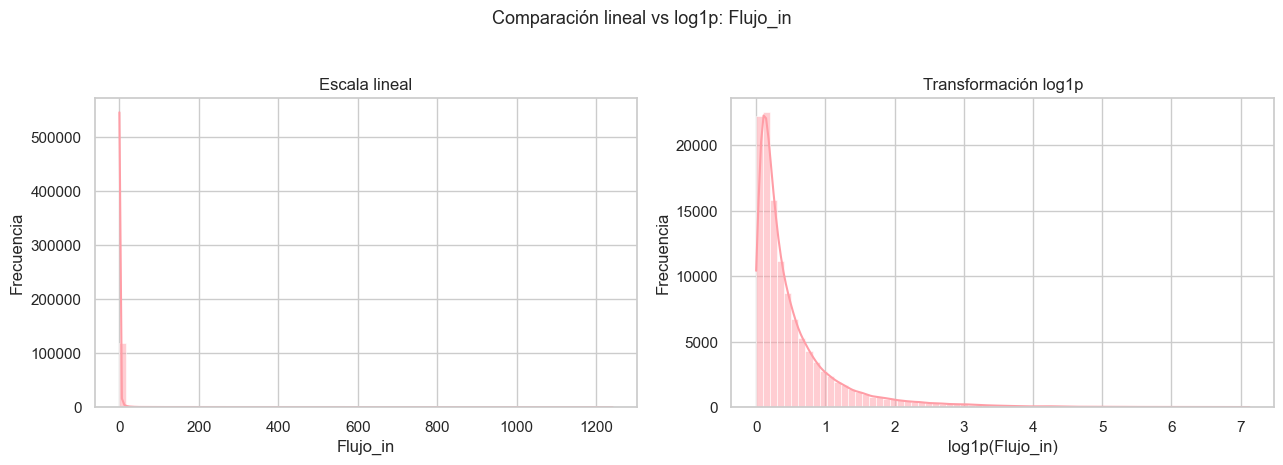

**Flujo_in** (Decimal (flujo/índice)). Indicador de movilidad entrante hacia el municipio. Rango observado: `0` a `1.34e+03`; mediana `0.351`; media `1.84`. Tiene faltantes bajos/moderados (`0.1%`), suficientes para documentar antes de cualquier transformación. Incluye ceros (`0.3%`), que deben preservarse porque suelen tener significado epidemiológico o ambiental. La asimetría positiva es marcada; las colas derechas pueden concentrar brotes, municipios grandes o eventos extremos, no errores por defecto. Implicación: la movilidad entrante suele tener cola derecha; valores extremos pueden representar municipios atractores o artefactos de medición que deben revisarse en outliers.

In [35]:
analizar_variable("poblacion", color=PALETTE["demografica"], bins=70, comparar_log=True)
analizar_variable("Flujo_in", color=PALETTE["flujo"], bins=70)


## 13. Mes como variable categórica

`MES` no se interpreta como variable continua. En este notebook solo se describe como categoría temporal para observar si el número de registros por mes es balanceado. El análisis estacional de casos corresponde al notebook temporal.


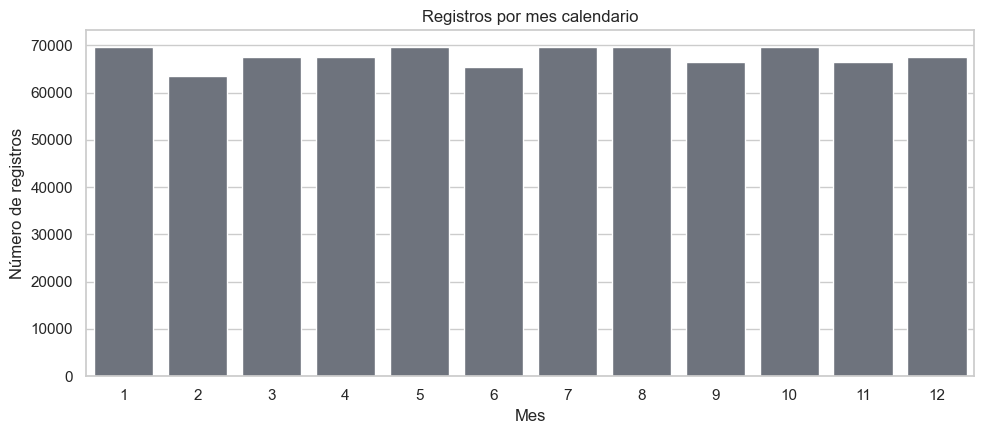

,MES,n_registros,porcentaje
0,1,69680,8.568
1,2,63440,7.801
2,3,67600,8.312
3,4,67600,8.312
4,5,69680,8.568
5,6,65520,8.056
6,7,69680,8.568
7,8,69680,8.568
8,9,66560,8.184
9,10,69680,8.568


In [36]:
mes_counts = df["MES"].value_counts().sort_index().rename_axis("MES").reset_index(name="n_registros")
mes_counts["porcentaje"] = mes_counts["n_registros"] / len(df) * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=mes_counts, x="MES", y="n_registros", color=PALETTE["gris"], ax=ax)
ax.set_title("Registros por mes calendario")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de registros")
plt.tight_layout()
fig.savefig(CATEGORICAS_TEMPORALES_PATH / "registros_por_mes_categoria.png", dpi=300, bbox_inches="tight")
plt.show()

mes_counts


## 14. Síntesis para próximos notebooks

Este análisis univariado confirma que varias variables del panel no son gaussianas, no son simétricas y no deberían tratarse con reglas automáticas de normalidad. Las decisiones posteriores deben respetar el tipo de variable, el significado de los ceros y el mecanismo de faltantes.


In [49]:
problemas_siguientes = pd.DataFrame(
    [
        ["casos_totales", "Alta masa en cero y cola derecha", "Evaluar log1p, tasas y métodos robustos antes de análisis multivariado."],
        ["casos por edad/sexo", "Conteos absolutos estratificados", "No interpretar como riesgo sin denominadores; usar principalmente para composición descriptiva."],
        ["estrato_1_2 / 3_4 / 5_plus", "Cobertura socioeconómica parcial y concentración en estratos 1-2", "Documentar sesgo de registro antes de imputar o comparar estratos."],
        ["temp_mean", "Faltantes altos", "Requiere estrategia explícita de imputación, restricción de muestra o análisis de sensibilidad."],
        ["prec_total", "Faltantes moderados, ceros y extremos", "Distinguir ceros reales de ausencias; considerar transformación para colas derechas."],
        ["poblacion", "Asimetría por municipios grandes", "Preferir tasas, offsets descriptivos o escalamiento en análisis posteriores."],
        ["Flujo_in", "Cola derecha y posibles extremos", "Revisar outliers y robustez antes de usarlo como proxy de movilidad."],
        ["COD_MUN_N, ANO, SEMANA, week_date, MES", "Variables índice/categóricas", "No analizarlas como distribuciones continuas; usarlas para agrupación, ordenamiento o estacionalidad."],
    ],
    columns=["Variable", "Problema identificado", "Implicación analítica"],
)

problemas_siguientes.to_csv(
    TABLES_PATH / "univariate_next_steps.csv",
    index=False,
    encoding="utf-8-sig",
)

problemas_siguientes


,Variable,Problema identificado,Implicación analítica
0,casos_totales,Alta masa en cero y cola derecha,"Evaluar log1p, tasas y métodos robustos antes ..."
1,casos por edad/sexo,Conteos absolutos estratificados,No interpretar como riesgo sin denominadores; ...
2,estrato_1_2 / 3_4 / 5_plus,Cobertura socioeconómica parcial y concentraci...,Documentar sesgo de registro antes de imputar ...
3,temp_mean,Faltantes altos,"Requiere estrategia explícita de imputación, r..."
4,prec_total,"Faltantes moderados, ceros y extremos",Distinguir ceros reales de ausencias; consider...
5,poblacion,Asimetría por municipios grandes,"Preferir tasas, offsets descriptivos o escalam..."
6,Flujo_in,Cola derecha y posibles extremos,Revisar outliers y robustez antes de usarlo co...
7,"COD_MUN_N, ANO, SEMANA, week_date, MES",Variables índice/categóricas,No analizarlas como distribuciones continuas; ...
